# Data Exploration: Processed Credit Risk Datasets

This notebook:
1. **Preprocesses** all raw datasets if the processed folder is empty (using `src.data.preprocessing`)
2. **Explores** the processed datasets with statistics and visualizations

Tasks covered:
- **PD (Probability of Default)**: Binary classification
- **LGD (Loss Given Default)**: Regression

In [1]:
import sys
from pathlib import Path

# Add project root to path (notebook is in notebooks/ folder)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit


In [2]:
# =============================================================================
# IMPORT PREPROCESSING FROM src/data/
# =============================================================================

from src.data.preprocessing import preprocess_dataset
from src.utils.config_reader import load_config

# Load configuration
config = load_config()

# Define directories
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

print(f"Raw data dir: {RAW_DIR} (exists: {RAW_DIR.exists()})")
print(f"Processed dir: {PROCESSED_DIR} (exists: {PROCESSED_DIR.exists()})")

Raw data dir: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\data\raw (exists: True)
Processed dir: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\data\processed (exists: True)


In [3]:
# =============================================================================
# GET AVAILABLE DATASETS FROM RAW FOLDER
# =============================================================================

def get_available_datasets(raw_dir: Path) -> dict:
    """Get list of available raw datasets (CSV and Parquet files)."""
    datasets = {'pd': [], 'lgd': []}
    
    if (raw_dir / 'pd').exists():
        csv_files = {f.stem for f in (raw_dir / 'pd').glob('*.csv')}
        parquet_files = {f.stem for f in (raw_dir / 'pd').glob('*.parquet')}
        datasets['pd'] = sorted(csv_files | parquet_files)  # Union of both
    
    if (raw_dir / 'lgd').exists():
        csv_files = {f.stem for f in (raw_dir / 'lgd').glob('*.csv')}
        parquet_files = {f.stem for f in (raw_dir / 'lgd').glob('*.parquet')}
        datasets['lgd'] = sorted(csv_files | parquet_files)  # Union of both
    
    return datasets

available_datasets = get_available_datasets(RAW_DIR)
print(f"Available PD datasets: {len(available_datasets['pd'])}")
for d in available_datasets['pd']:
    print(f"  - {d}")
print(f"\nAvailable LGD datasets: {len(available_datasets['lgd'])}")
for d in available_datasets['lgd']:
    print(f"  - {d}")

Available PD datasets: 15
  - 0001.gmsc
  - 0002.taiwan_creditcard
  - 0003.vehicle_loan
  - 0004.lendingclub
  - 0005.case_study
  - 0006.myhom
  - 0007.hackerearth
  - 0008.cobranded
  - 0009.german
  - 0010.bank_status
  - 0011.thomas
  - 0012.loan_default
  - 0013.home_credit
  - 0014.hmeq
  - 0015.algorithmwatch

Available LGD datasets: 5
  - 0001.heloc
  - 0002.loss2
  - 0003.axa
  - 0004.base_model
  - 0005.base_modelisation


---
## Part 1: Preprocess All Datasets (if needed)

In [4]:
# =============================================================================
# CHECK IF PREPROCESSING IS NEEDED
# =============================================================================

def check_processed_exists(processed_dir: Path) -> dict:
    """Check which datasets are already processed."""
    processed = {'pd': [], 'lgd': []}
    
    pd_dir = processed_dir / 'pd'
    lgd_dir = processed_dir / 'lgd'
    
    if pd_dir.exists():
        # Check for dataset folders with y.npy files
        for d in pd_dir.iterdir():
            if d.is_dir() and (d / 'y.npy').exists():
                processed['pd'].append(d.name)
    
    if lgd_dir.exists():
        for d in lgd_dir.iterdir():
            if d.is_dir() and (d / 'y.npy').exists():
                processed['lgd'].append(d.name)
    
    return processed

processed_datasets = check_processed_exists(PROCESSED_DIR)
print(f"Already processed PD: {len(processed_datasets['pd'])}")
print(f"Already processed LGD: {len(processed_datasets['lgd'])}")

Already processed PD: 0
Already processed LGD: 0


In [5]:
# =============================================================================
# PREPROCESS ALL DATASETS
# =============================================================================

def preprocess_all_datasets(available: dict, processed: dict):
    """Preprocess all datasets that haven't been processed yet."""
    
    # PD datasets
    pd_to_process = [d for d in available['pd'] if d not in processed['pd']]
    if pd_to_process:
        print("=" * 60)
        print(f" PREPROCESSING {len(pd_to_process)} PD DATASETS")
        print("=" * 60)
        for dataset in pd_to_process:
            try:
                print(f"\nProcessing: {dataset}")
                N, C, y, info = preprocess_dataset('pd', dataset)
                print(f"  Done: {info['n_samples']} samples, {info['n_num_features']} num, {info['n_cat_features']} cat")
            except Exception as e:
                print(f"  ERROR: {e}")
    else:
        print("All PD datasets already processed.")
    
    # LGD datasets
    lgd_to_process = [d for d in available['lgd'] if d not in processed['lgd']]
    if lgd_to_process:
        print("\n" + "=" * 60)
        print(f" PREPROCESSING {len(lgd_to_process)} LGD DATASETS")
        print("=" * 60)
        for dataset in lgd_to_process:
            try:
                print(f"\nProcessing: {dataset}")
                N, C, y, info = preprocess_dataset('lgd', dataset)
                print(f"  Done: {info['n_samples']} samples, {info['n_num_features']} num, {info['n_cat_features']} cat")
            except Exception as e:
                print(f"  ERROR: {e}")
    else:
        print("All LGD datasets already processed.")

# Run preprocessing
preprocess_all_datasets(available_datasets, processed_datasets)

# Update processed list
processed_datasets = check_processed_exists(PROCESSED_DIR)
print(f"\nTotal processed - PD: {len(processed_datasets['pd'])}, LGD: {len(processed_datasets['lgd'])}")

 PREPROCESSING 15 PD DATASETS

Processing: 0001.gmsc
  Done: 150000 samples, 10 num, 0 cat

Processing: 0002.taiwan_creditcard
  Done: 30000 samples, 23 num, 0 cat

Processing: 0003.vehicle_loan
  Done: 233154 samples, 32 num, 3 cat

Processing: 0004.lendingclub
  Done: 9578 samples, 12 num, 1 cat

Processing: 0005.case_study
  Done: 150000 samples, 10 num, 1 cat

Processing: 0006.myhom
  Done: 7000 samples, 7 num, 1 cat

Processing: 0007.hackerearth
  Done: 532428 samples, 35 num, 8 cat

Processing: 0008.cobranded
  Done: 80000 samples, 47 num, 0 cat

Processing: 0009.german
  Done: 999 samples, 7 num, 13 cat

Processing: 0010.bank_status
  Done: 100000 samples, 16 num, 0 cat

Processing: 0011.thomas
  Done: 1225 samples, 12 num, 2 cat

Processing: 0012.loan_default
  Done: 105471 samples, 99 num, 0 cat

Processing: 0013.home_credit
  Done: 307511 samples, 99 num, 0 cat

Processing: 0014.hmeq
  Done: 5960 samples, 10 num, 2 cat

Processing: 0015.algorithmwatch
  Done: 158700 samples, 

---
## Part 2: Data Exploration Functions

In [6]:
# =============================================================================
# EXPLORATION HELPER FUNCTIONS
# =============================================================================

import json

def load_processed_dataset(task: str, dataset: str) -> tuple:
    """Load a processed dataset (N, C, y, info)."""
    dataset_dir = PROCESSED_DIR / task / dataset
    
    if not (dataset_dir / 'y.npy').exists():
        return None, None, None, None
    
    N = np.load(dataset_dir / 'N.npy') if (dataset_dir / 'N.npy').exists() else None
    C = np.load(dataset_dir / 'C.npy') if (dataset_dir / 'C.npy').exists() else None
    y = np.load(dataset_dir / 'y.npy')
    
    with open(dataset_dir / 'info.json') as f:
        info = json.load(f)
    
    return N, C, y, info


def plot_target_distribution(y: np.ndarray, task: str, dataset_name: str):
    """Plot target variable distribution."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    if task == 'pd':
        unique, counts = np.unique(y, return_counts=True)
        axes[0].bar([str(int(u)) for u in unique], counts, color=['steelblue', 'coral'], edgecolor='black')
        axes[0].set_xlabel('Class')
        axes[0].set_ylabel('Count')
        axes[0].set_title('Class Distribution')
        for i, (u, c) in enumerate(zip(unique, counts)):
            axes[0].annotate(f'{100*c/len(y):.1f}%', xy=(i, c), ha='center', va='bottom')
        axes[1].pie(counts, labels=[f'Class {int(u)}' for u in unique], autopct='%1.1f%%', colors=['steelblue', 'coral'])
        axes[1].set_title('Class Proportion')
    else:
        axes[0].hist(y, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        axes[0].axvline(x=np.mean(y), color='red', linestyle='--', label=f'Mean: {np.mean(y):.3f}')
        axes[0].axvline(x=np.median(y), color='green', linestyle='--', label=f'Median: {np.median(y):.3f}')
        axes[0].set_xlabel('LGD')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title('Target Distribution')
        axes[0].legend()
        axes[1].boxplot(y, vert=True)
        axes[1].set_ylabel('LGD')
        axes[1].set_title('Target Box Plot')
    
    plt.suptitle(f'{dataset_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_feature_distributions(N: np.ndarray, info: dict, dataset_name: str):
    """Plot numeric feature distributions."""
    if N is None or N.shape[1] == 0:
        print("No numeric features to plot.")
        return
    
    n_features = min(12, N.shape[1])
    n_rows = (n_features + 3) // 4
    
    fig, axes = plt.subplots(n_rows, 4, figsize=(16, 3 * n_rows))
    axes = axes.flatten()
    
    num_cols = info.get('numerical_cols', [f'num_{i}' for i in range(N.shape[1])])
    
    for i in range(n_features):
        col_name = num_cols[i] if i < len(num_cols) else f'num_{i}'
        data = N[:, i]
        data = data[~np.isnan(data)]
        axes[i].hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[i].set_title(col_name[:20], fontsize=10)
        axes[i].tick_params(labelsize=8)
    
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(f'{dataset_name} - Feature Distributions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(N: np.ndarray, y: np.ndarray, info: dict, dataset_name: str):
    """Plot correlation heatmap."""
    if N is None or N.shape[1] < 2:
        print("Not enough numeric features for correlation.")
        return
    
    # Combine N and y for correlation
    data = np.column_stack([N, y])
    
    # Handle NaN
    df = pd.DataFrame(data)
    corr_matrix = df.corr()
    
    # Get top correlated with target
    target_corr = corr_matrix.iloc[:-1, -1].abs().sort_values(ascending=False)
    top_indices = target_corr.head(14).index.tolist()
    top_indices.append(len(corr_matrix) - 1)  # Add target
    
    sub_corr = corr_matrix.iloc[top_indices, top_indices]
    
    # Create labels
    num_cols = info.get('numerical_cols', [f'num_{i}' for i in range(N.shape[1])])
    labels = [num_cols[i][:15] if i < len(num_cols) else f'num_{i}' for i in top_indices[:-1]] + ['target']
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(sub_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                xticklabels=labels, yticklabels=labels,
                square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
    plt.title(f'{dataset_name} - Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def explore_dataset(task: str, dataset: str) -> dict:
    """Comprehensive exploration of a single dataset."""
    print("\n" + "=" * 80)
    print(f" DATASET: {dataset} ({task.upper()})")
    print("=" * 80)
    
    N, C, y, info = load_processed_dataset(task, dataset)
    if y is None:
        print("Dataset not found!")
        return None
    
    # Basic statistics
    print(f"\n[BASIC STATISTICS]")
    print(f"  Samples:          {info['n_samples']:,}")
    print(f"  Numeric features: {info['n_num_features']}")
    print(f"  Categorical feat: {info['n_cat_features']}")
    print(f"  Total features:   {info['n_num_features'] + info['n_cat_features']}")
    
    # Target statistics
    print(f"\n[TARGET VARIABLE]")
    if task == 'pd':
        unique, counts = np.unique(y, return_counts=True)
        for u, c in zip(unique, counts):
            print(f"  Class {int(u)}: {c:,} ({100*c/len(y):.1f}%)")
        print(f"  Imbalance ratio: {counts.max()/counts.min():.2f}:1")
    else:
        print(f"  Min: {y.min():.4f}  Max: {y.max():.4f}")
        print(f"  Mean: {y.mean():.4f}  Median: {np.median(y):.4f}  Std: {y.std():.4f}")
        n_zero = (y == 0).sum()
        n_one = (y == 1).sum()
        print(f"  Values=0: {n_zero} ({100*n_zero/len(y):.1f}%)  Values=1: {n_one} ({100*n_one/len(y):.1f}%)")
    
    # Visualizations
    plot_target_distribution(y, task, dataset)
    plot_feature_distributions(N, info, dataset)
    plot_correlation_heatmap(N, y, info, dataset)
    
    return {
        'name': dataset,
        'task': task,
        'n_samples': info['n_samples'],
        'n_num_features': info['n_num_features'],
        'n_cat_features': info['n_cat_features'],
        'n_total_features': info['n_num_features'] + info['n_cat_features']
    }

---
## Part 3: Explore PD Datasets

Exploring 15 PD datasets...

 DATASET: 0001.gmsc (PD)

[BASIC STATISTICS]
  Samples:          150,000
  Numeric features: 10
  Categorical feat: 0
  Total features:   10

[TARGET VARIABLE]
  Class 0: 139,974 (93.3%)
  Class 1: 10,026 (6.7%)
  Imbalance ratio: 13.96:1


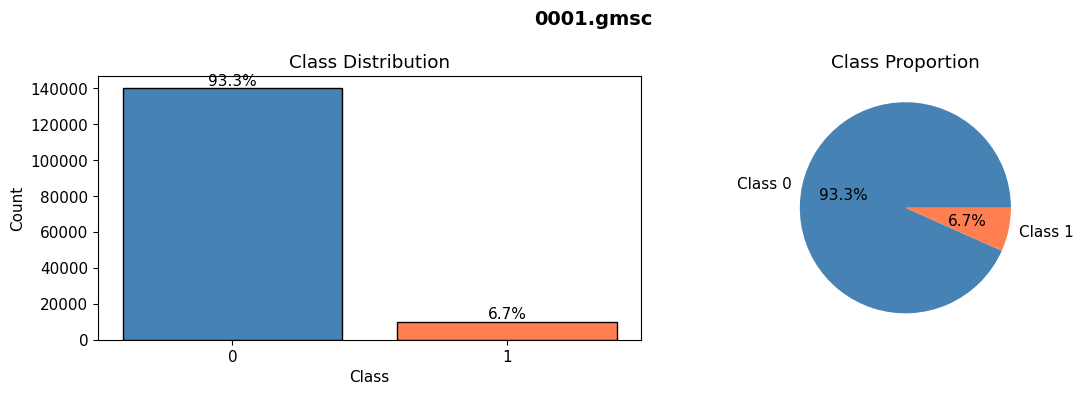

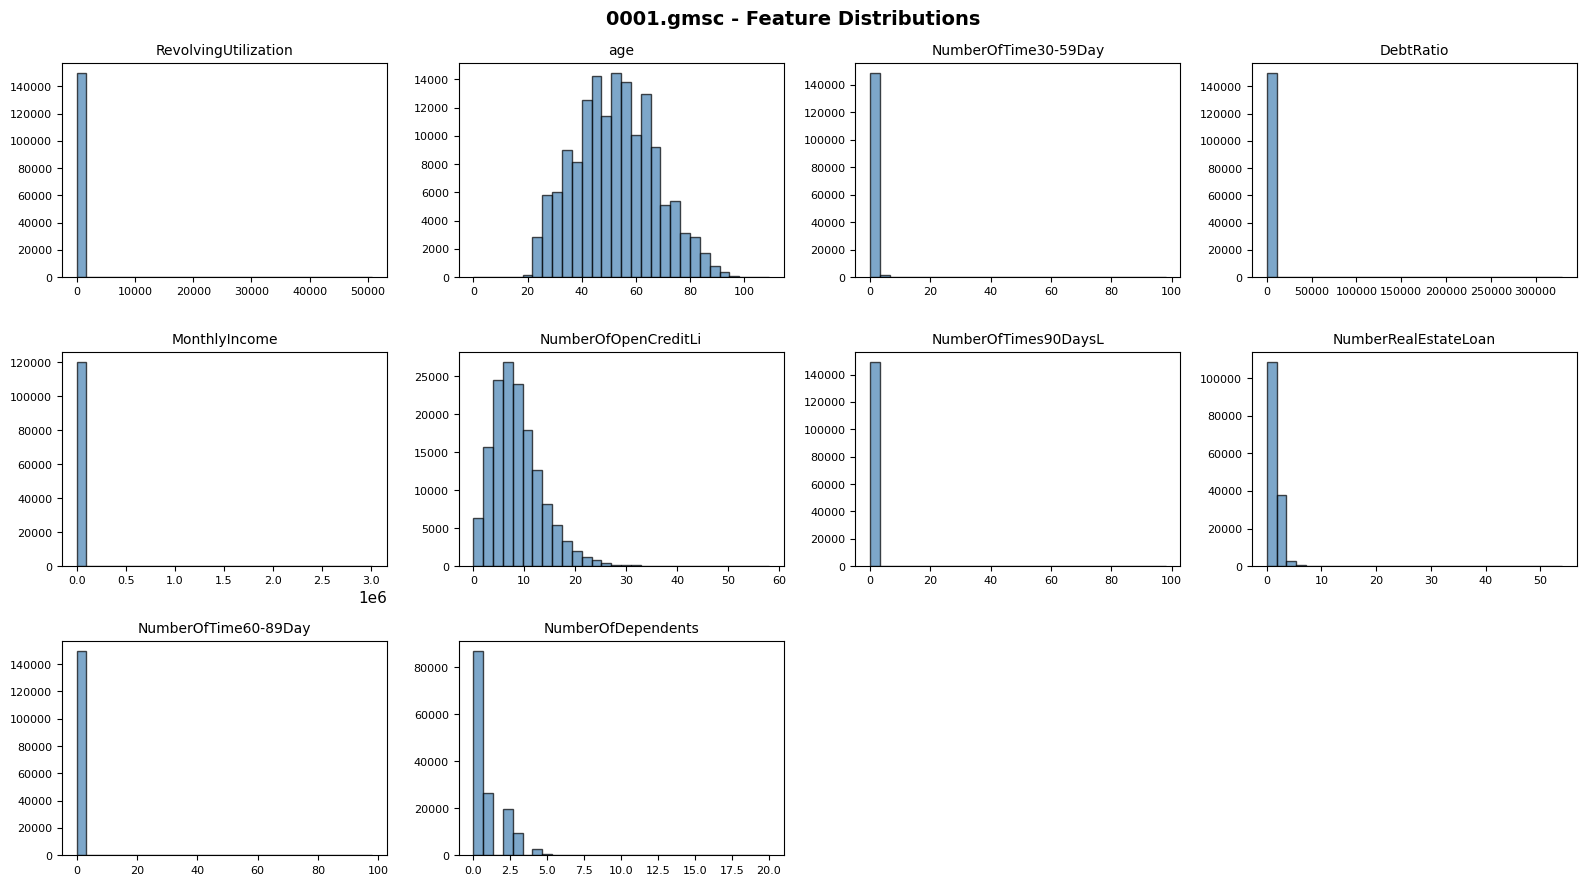

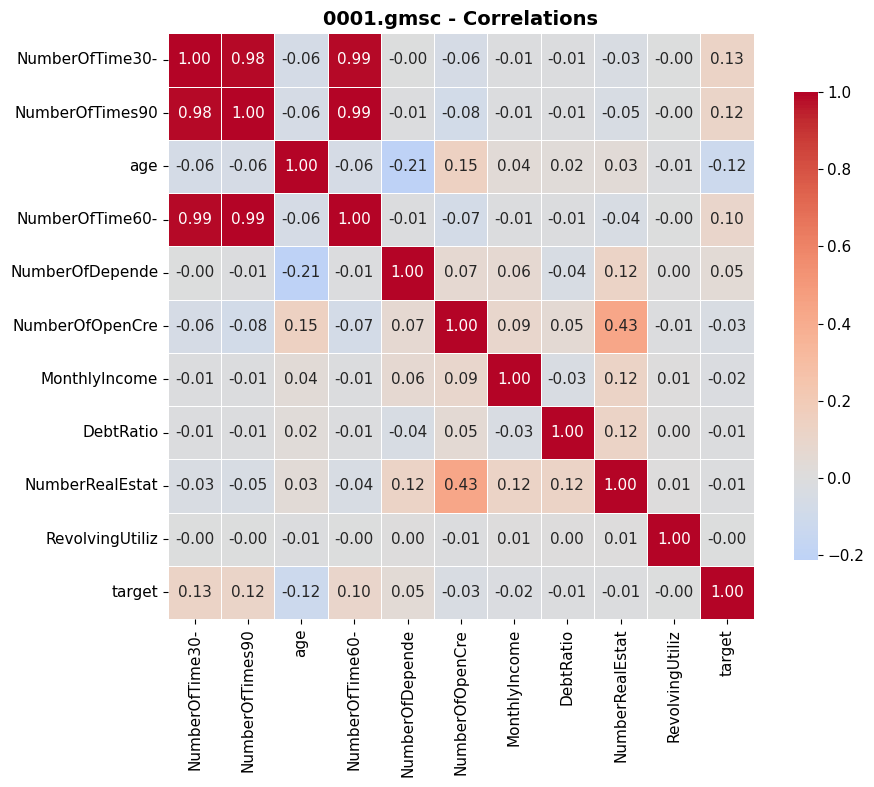


 DATASET: 0002.taiwan_creditcard (PD)

[BASIC STATISTICS]
  Samples:          30,000
  Numeric features: 23
  Categorical feat: 0
  Total features:   23

[TARGET VARIABLE]
  Class 0: 23,364 (77.9%)
  Class 1: 6,636 (22.1%)
  Imbalance ratio: 3.52:1


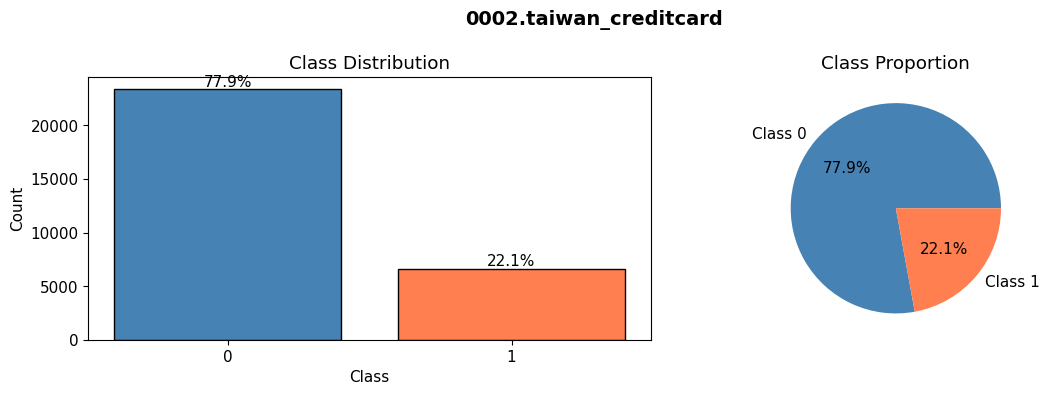

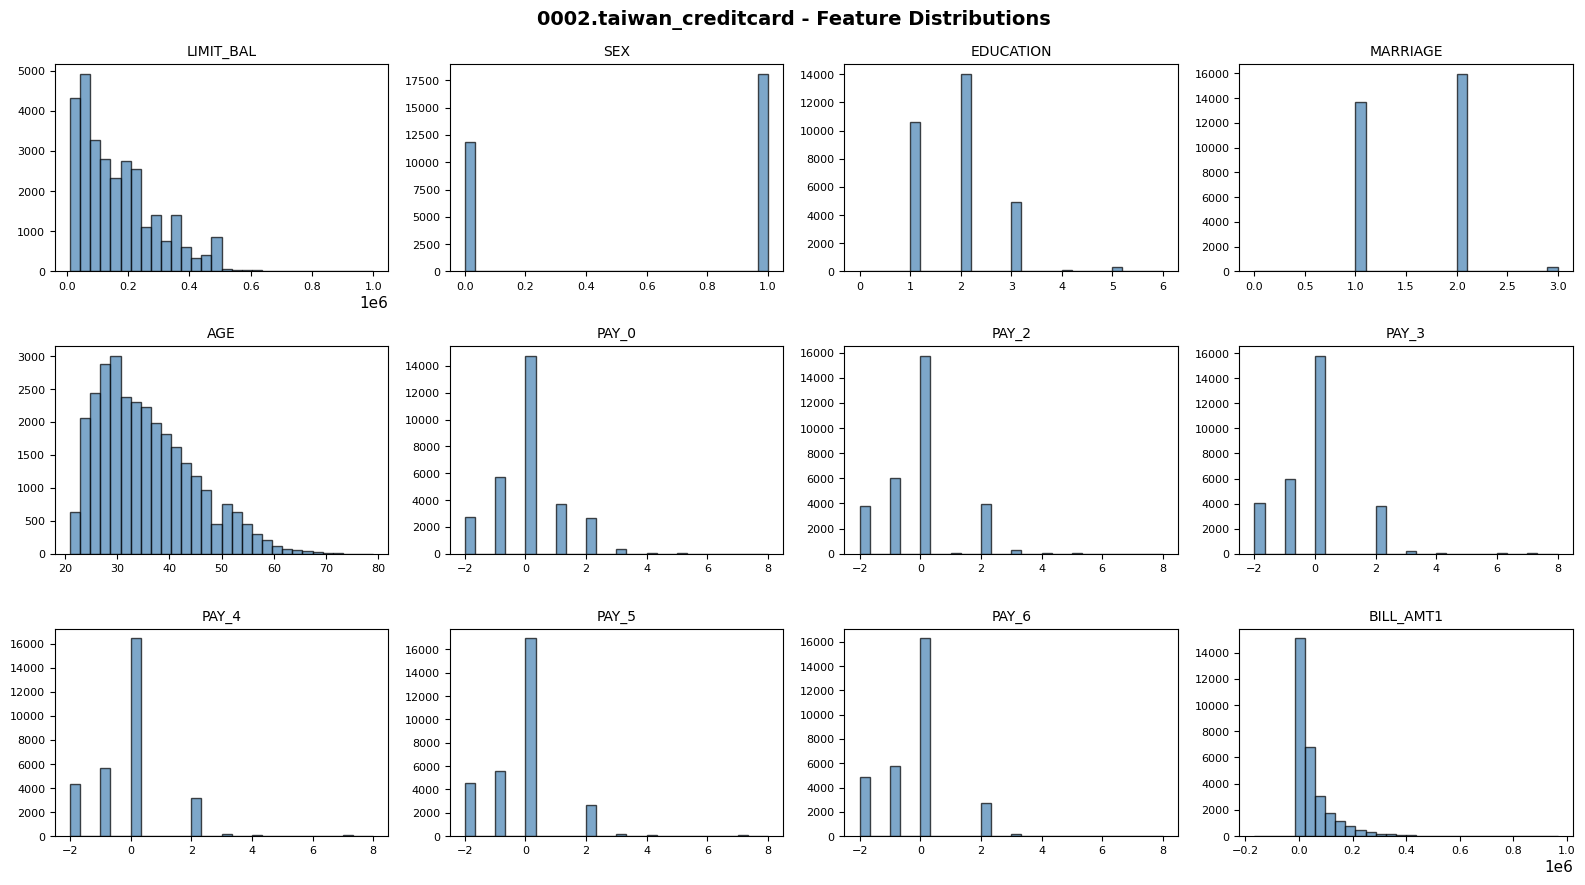

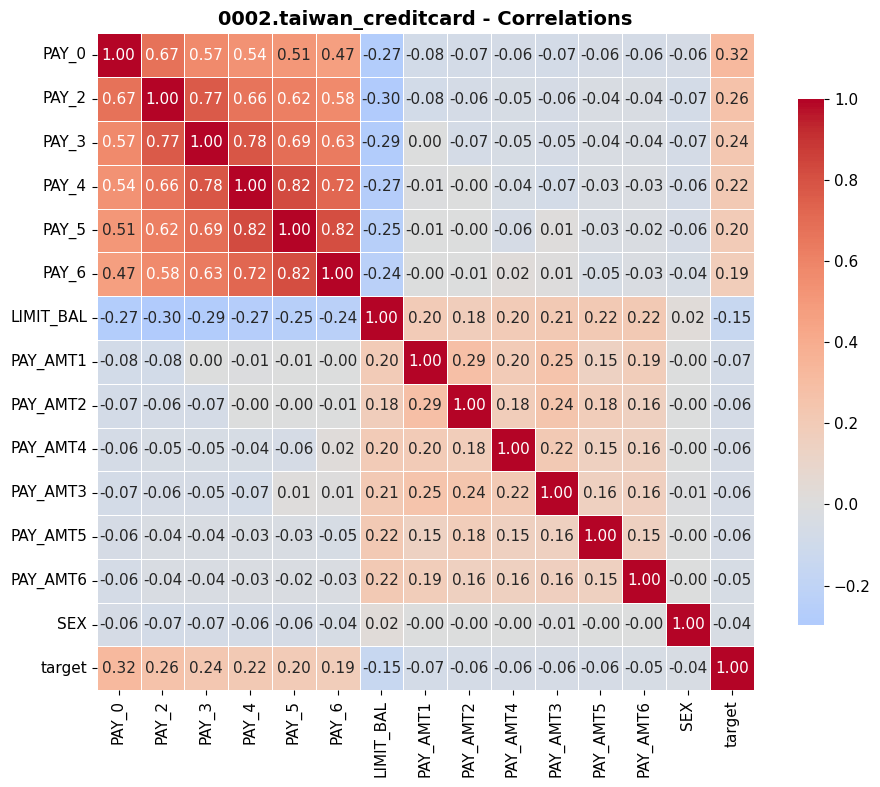


 DATASET: 0003.vehicle_loan (PD)

[BASIC STATISTICS]
  Samples:          233,154
  Numeric features: 32
  Categorical feat: 3
  Total features:   35

[TARGET VARIABLE]
  Class 0: 182,543 (78.3%)
  Class 1: 50,611 (21.7%)
  Imbalance ratio: 3.61:1


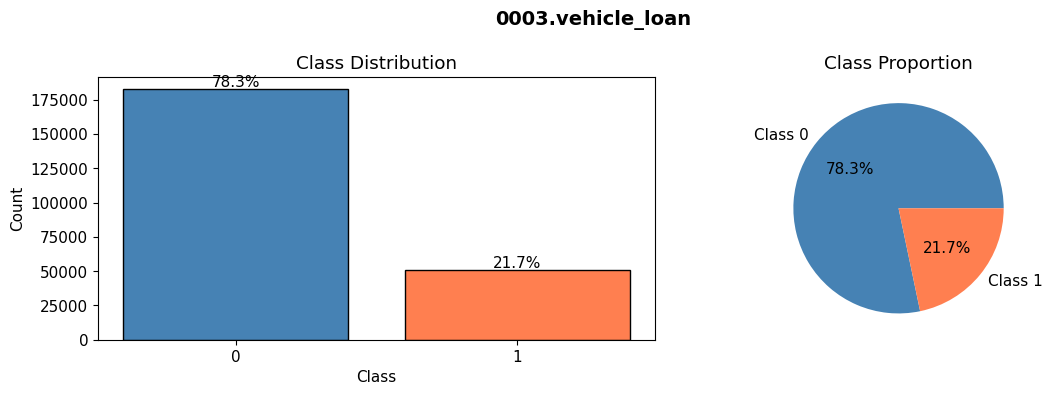

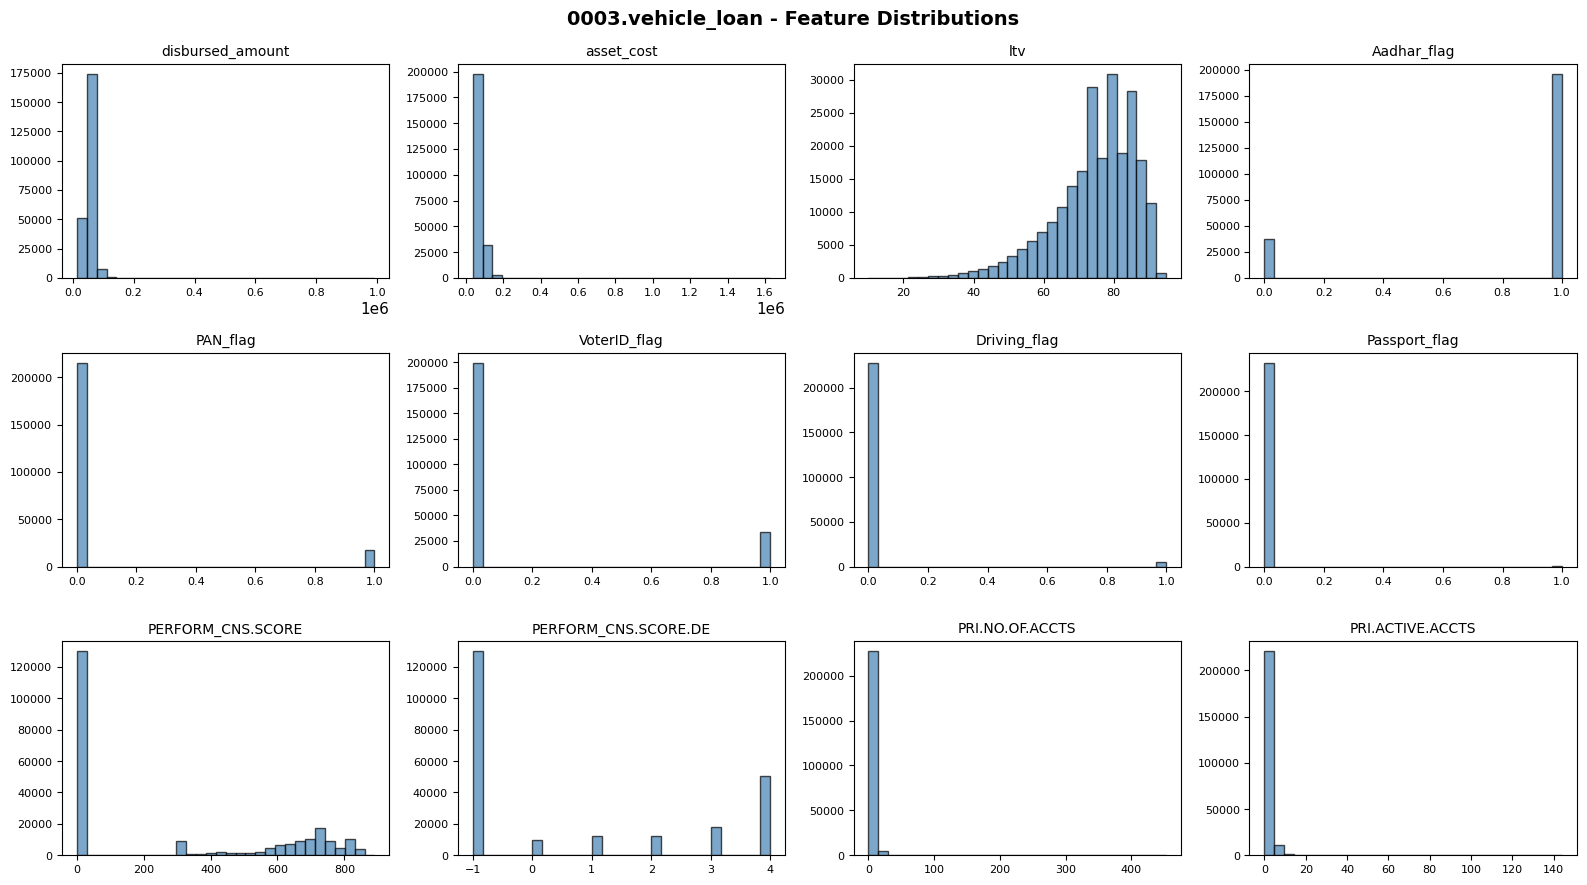

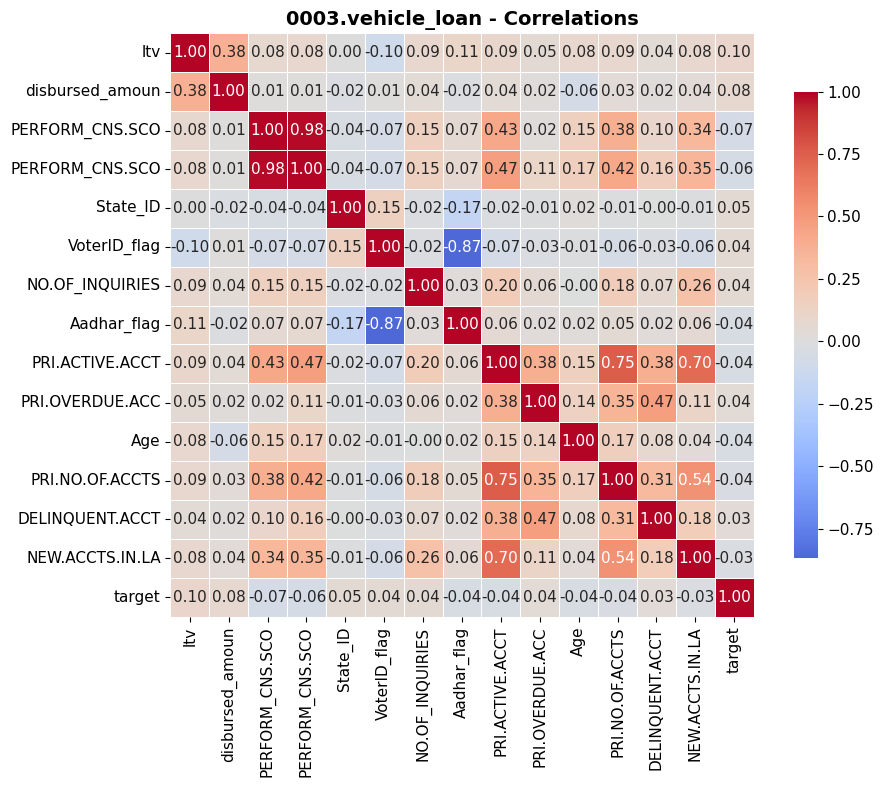


 DATASET: 0004.lendingclub (PD)

[BASIC STATISTICS]
  Samples:          9,578
  Numeric features: 12
  Categorical feat: 1
  Total features:   13

[TARGET VARIABLE]
  Class 0: 8,045 (84.0%)
  Class 1: 1,533 (16.0%)
  Imbalance ratio: 5.25:1


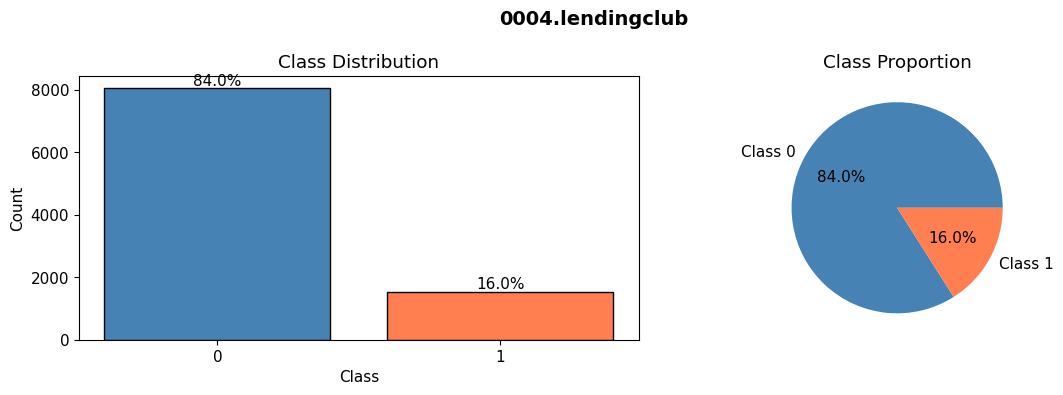

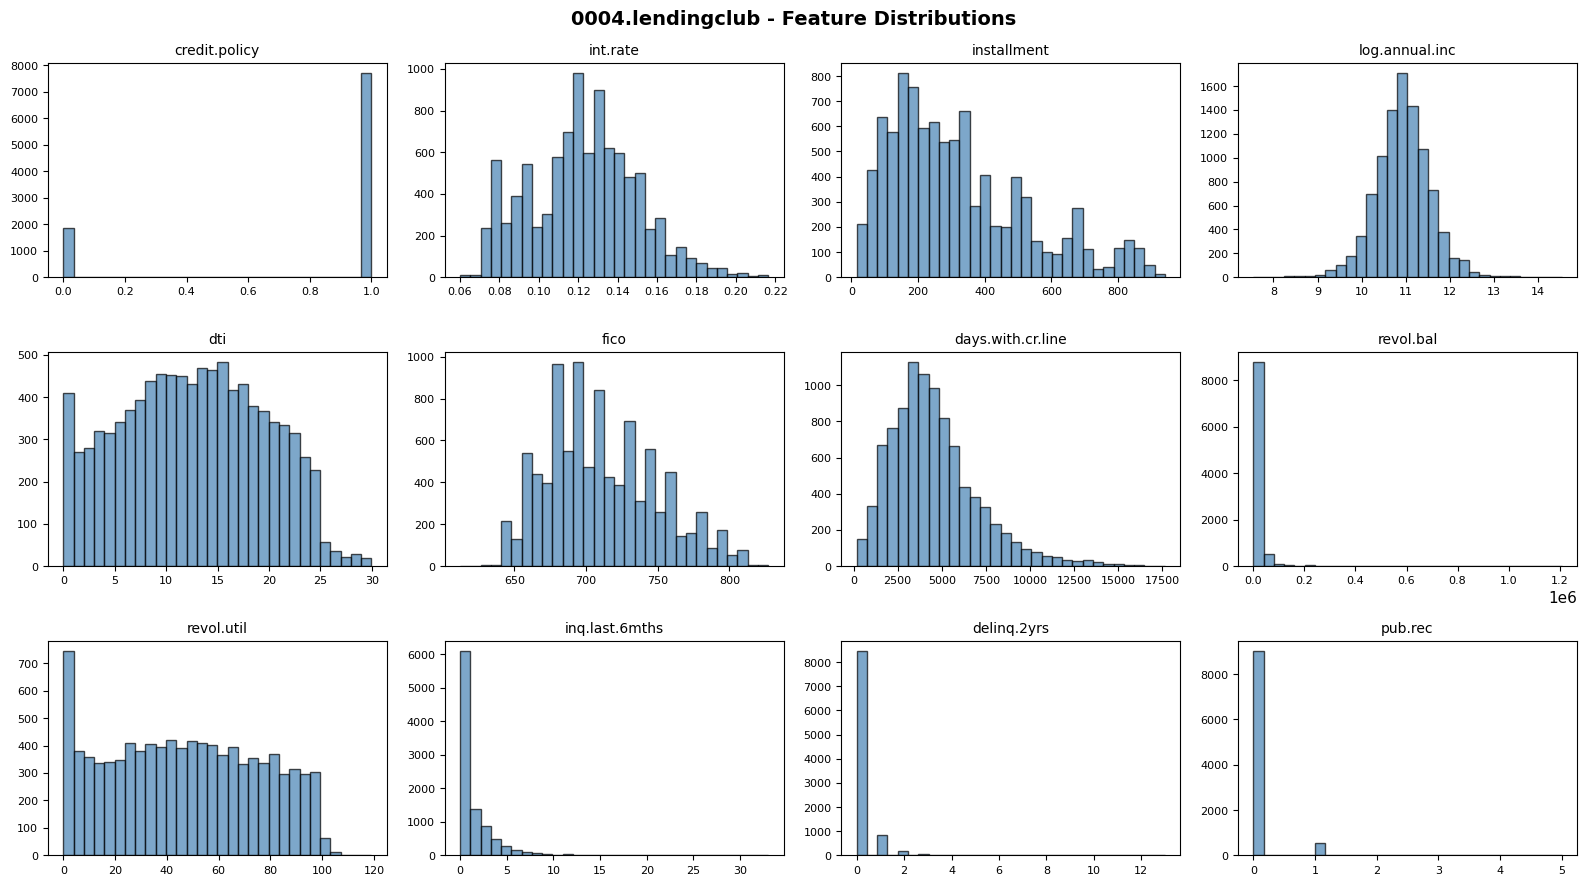

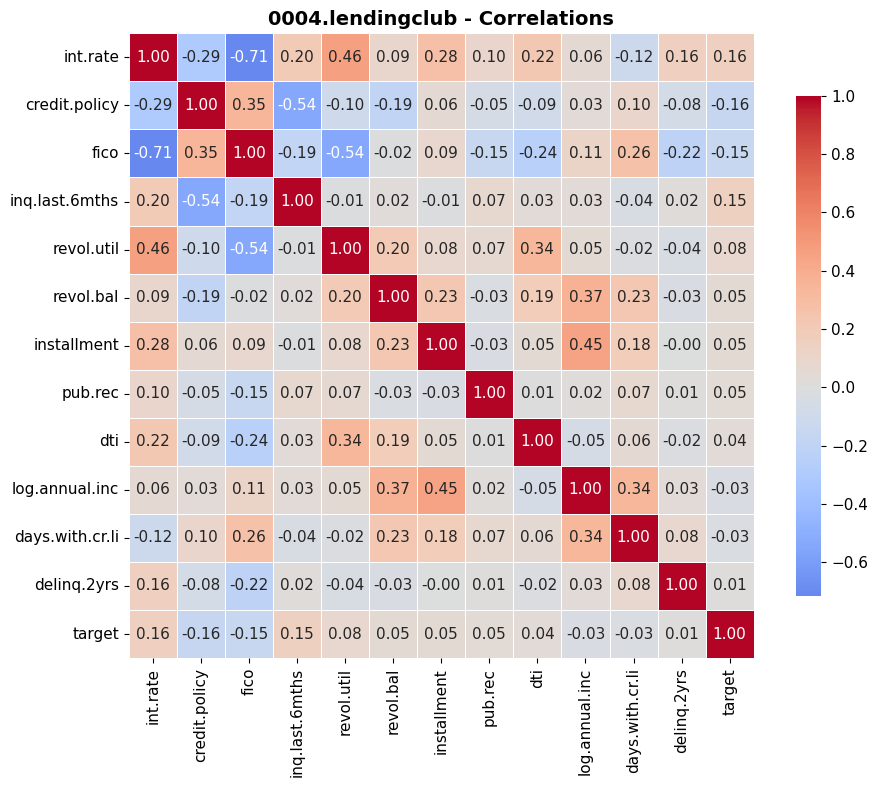


 DATASET: 0005.case_study (PD)

[BASIC STATISTICS]
  Samples:          150,000
  Numeric features: 10
  Categorical feat: 1
  Total features:   11

[TARGET VARIABLE]
  Class 0: 139,974 (93.3%)
  Class 1: 10,026 (6.7%)
  Imbalance ratio: 13.96:1


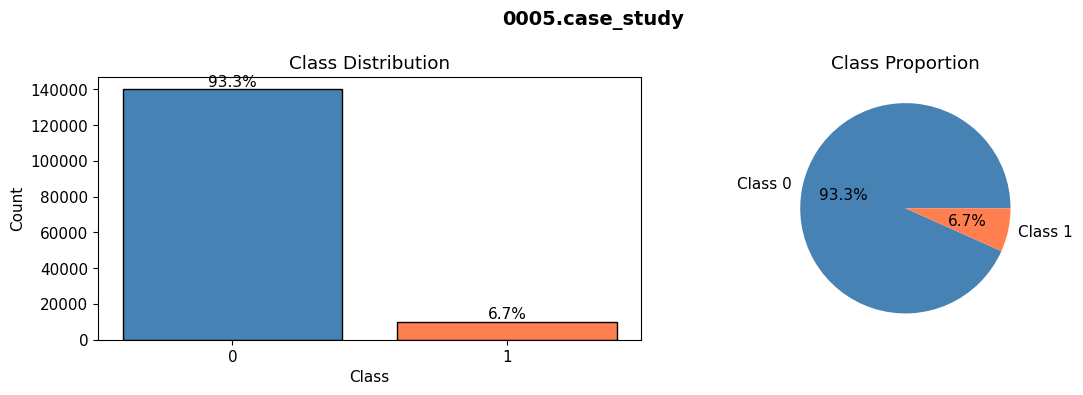

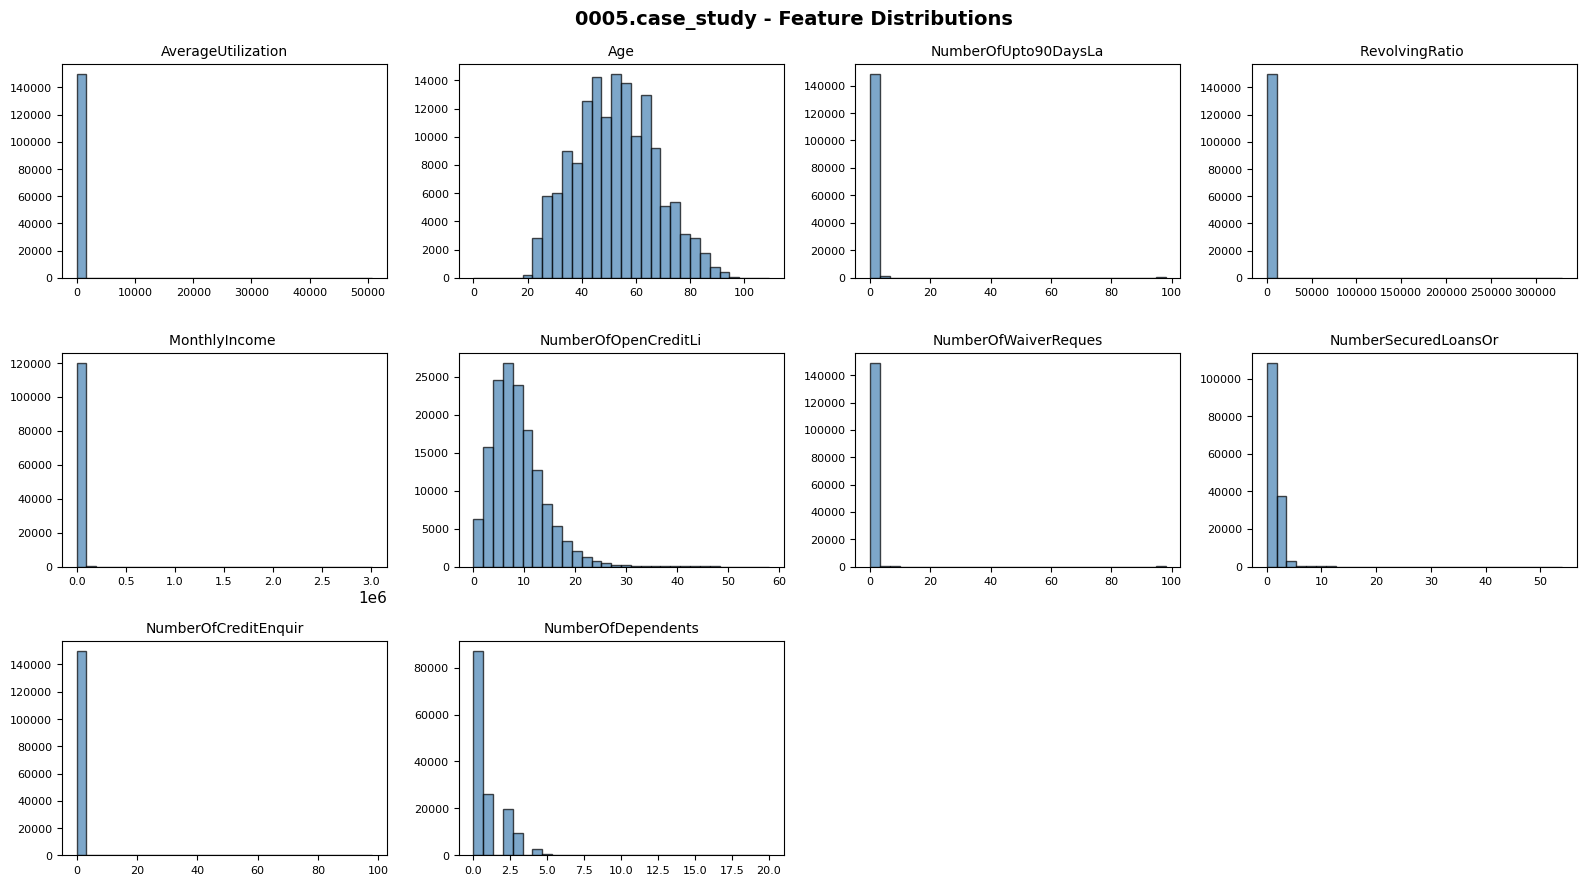

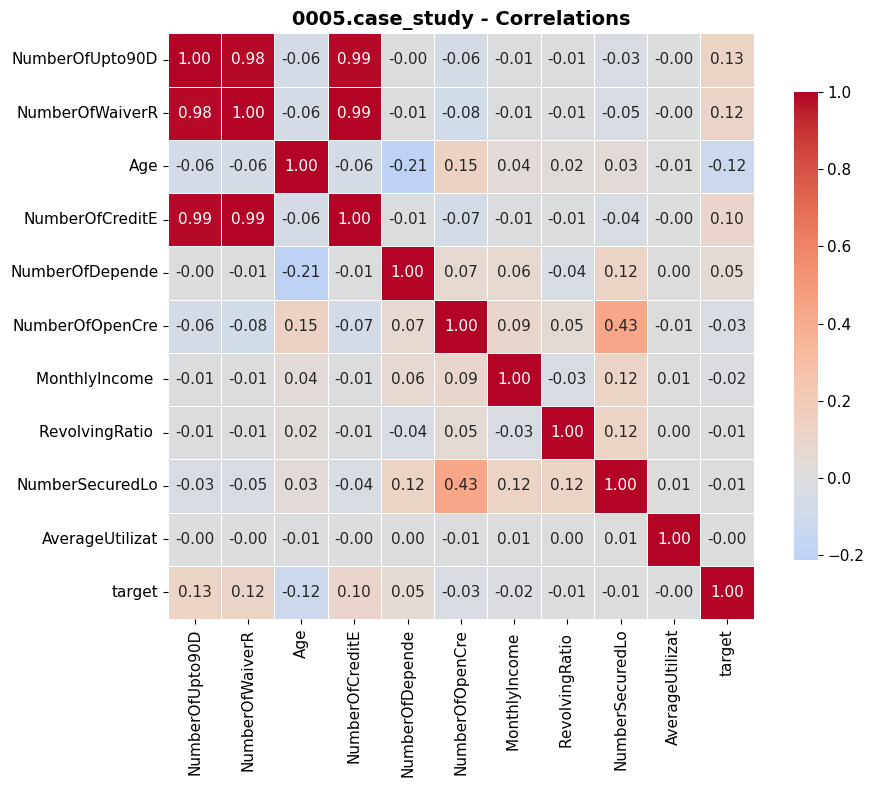


 DATASET: 0006.myhom (PD)

[BASIC STATISTICS]
  Samples:          7,000
  Numeric features: 7
  Categorical feat: 1
  Total features:   8

[TARGET VARIABLE]
  Class 0: 4,200 (60.0%)
  Class 1: 2,800 (40.0%)
  Imbalance ratio: 1.50:1


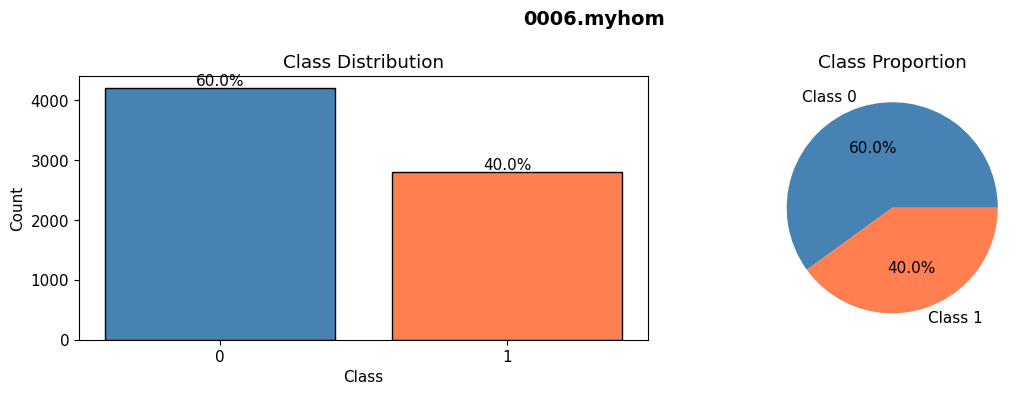

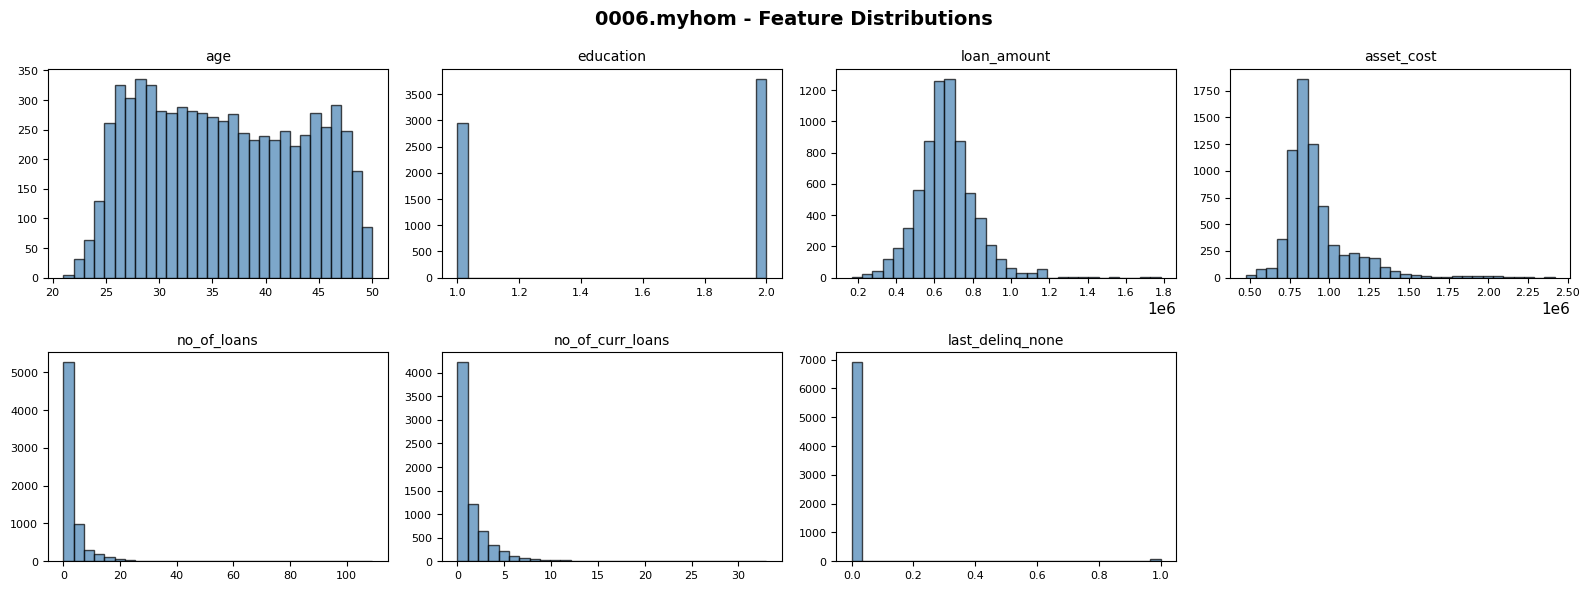

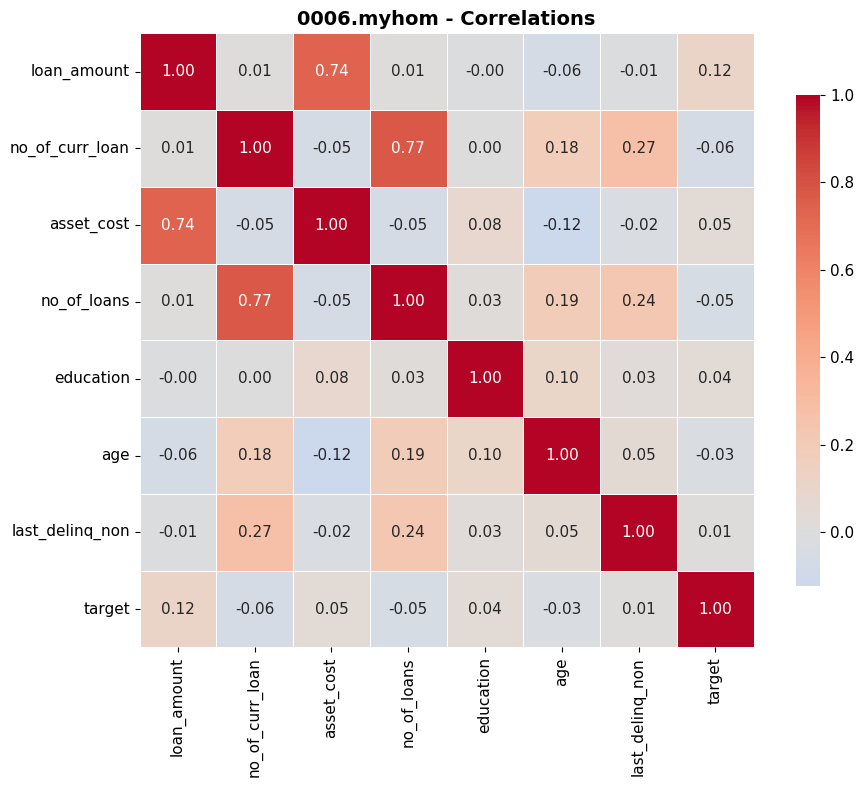


 DATASET: 0007.hackerearth (PD)

[BASIC STATISTICS]
  Samples:          532,428
  Numeric features: 35
  Categorical feat: 8
  Total features:   43

[TARGET VARIABLE]
  Class 0: 406,601 (76.4%)
  Class 1: 125,827 (23.6%)
  Imbalance ratio: 3.23:1


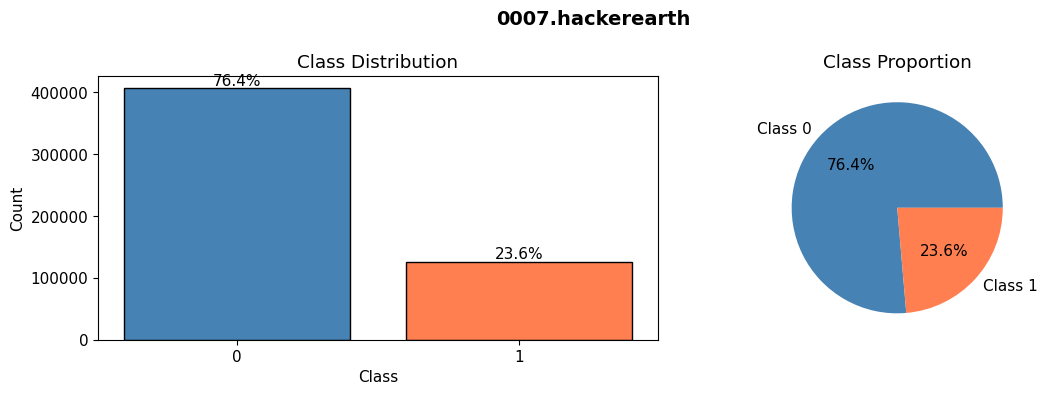

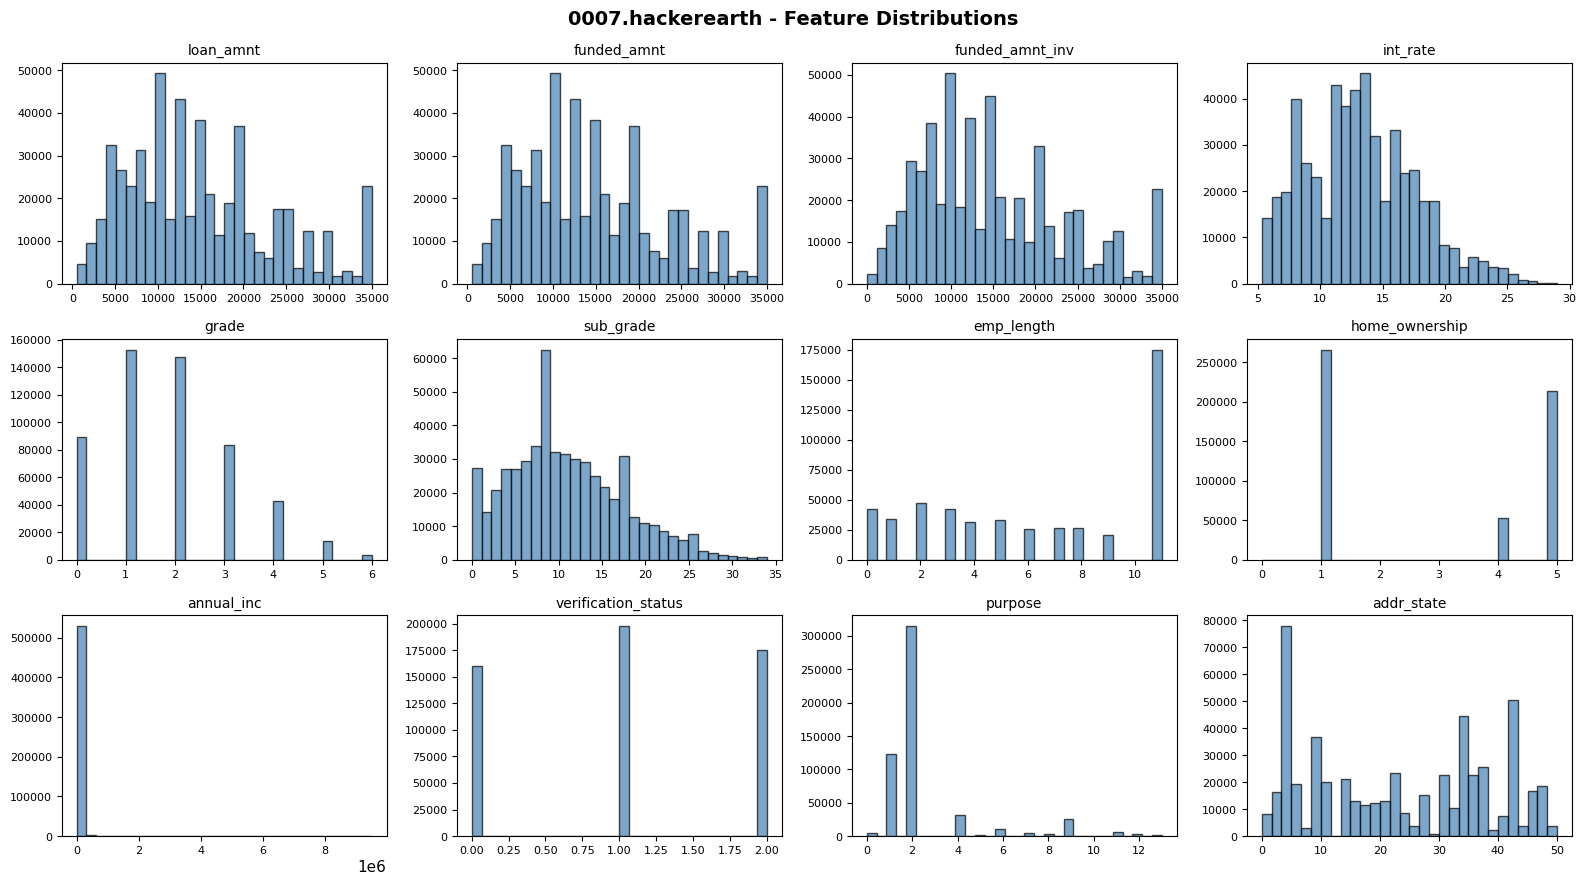

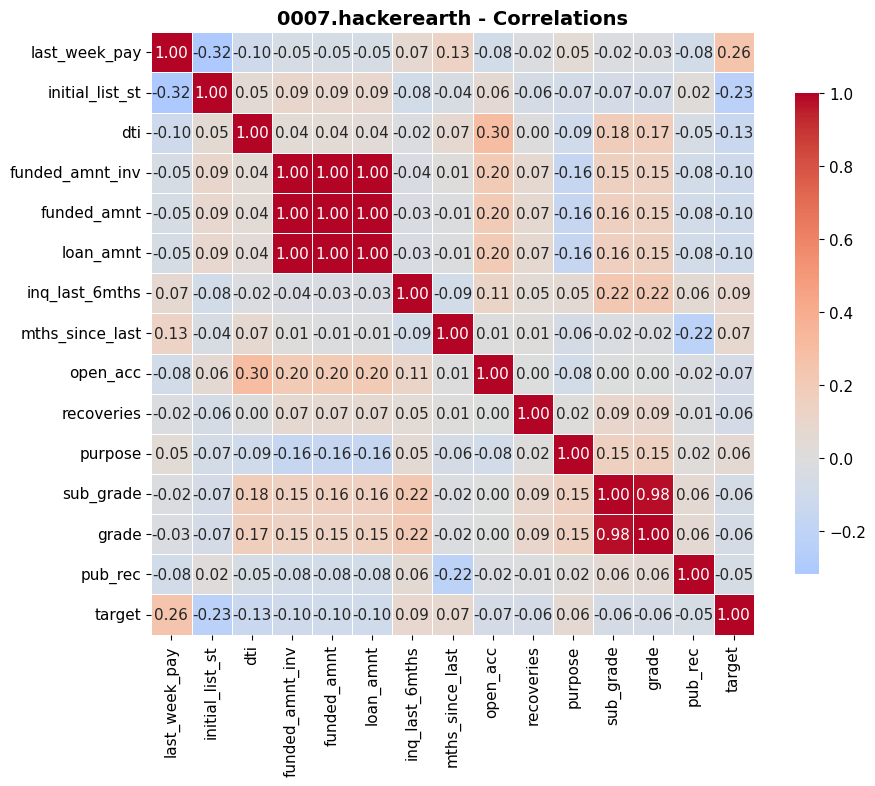


 DATASET: 0008.cobranded (PD)

[BASIC STATISTICS]
  Samples:          80,000
  Numeric features: 47
  Categorical feat: 0
  Total features:   47

[TARGET VARIABLE]
  Class 0: 60,303 (75.4%)
  Class 1: 19,697 (24.6%)
  Imbalance ratio: 3.06:1


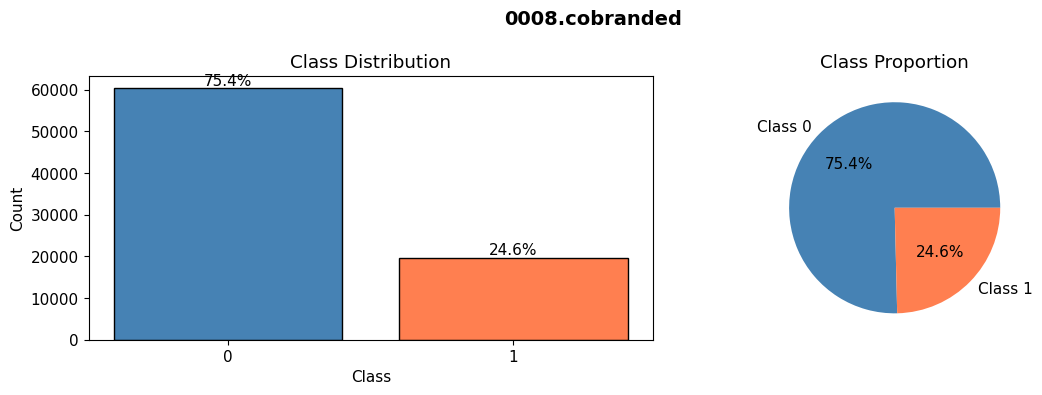

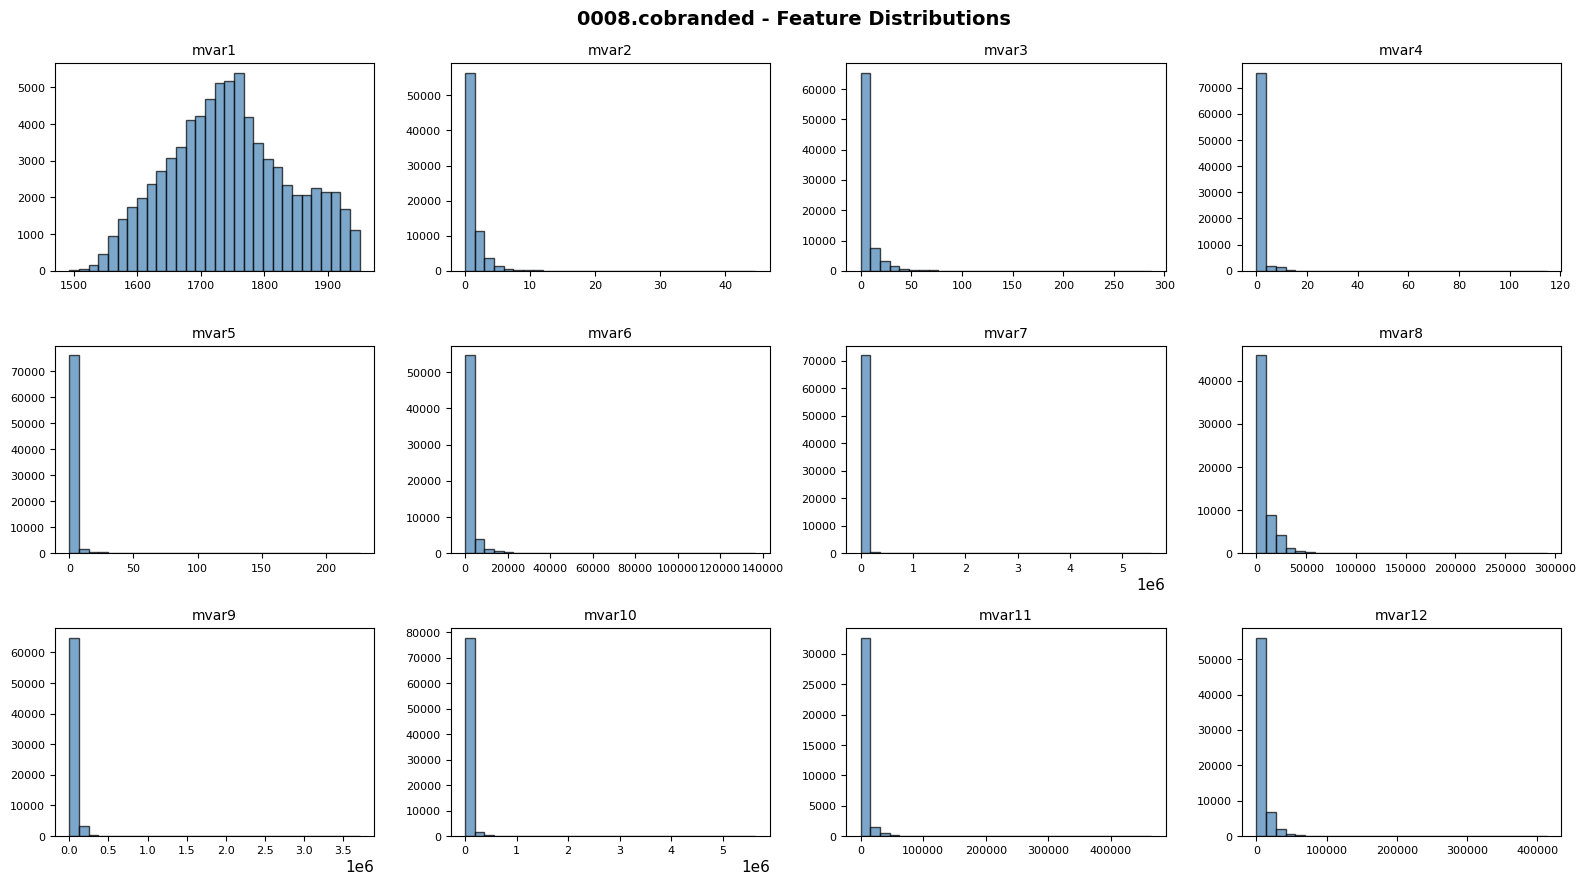

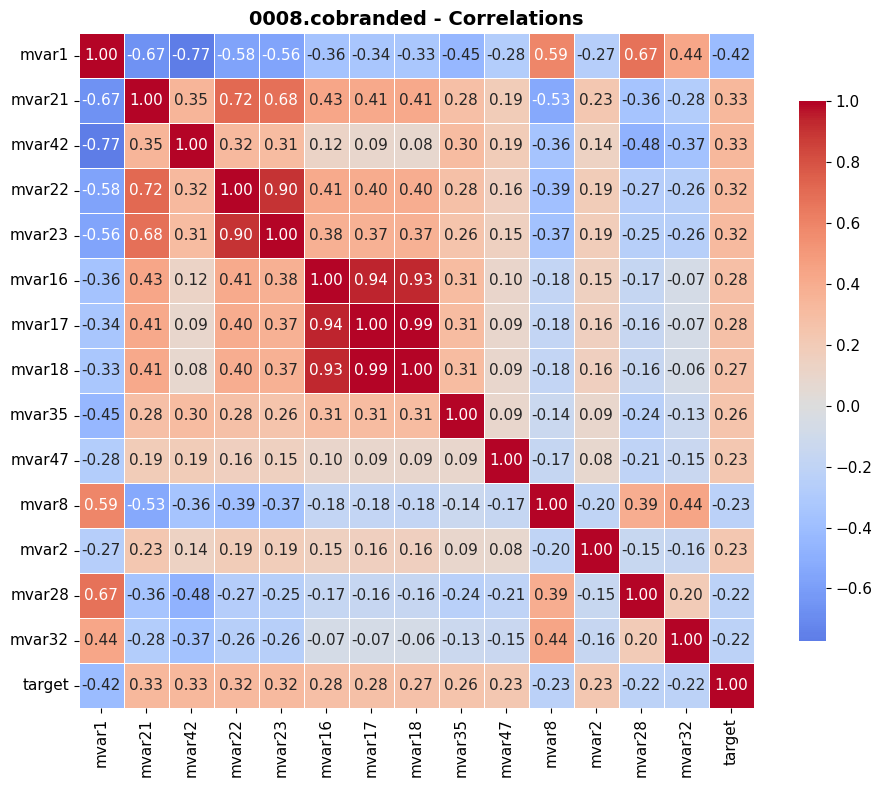


 DATASET: 0009.german (PD)

[BASIC STATISTICS]
  Samples:          999
  Numeric features: 7
  Categorical feat: 13
  Total features:   20

[TARGET VARIABLE]
  Class 0: 699 (70.0%)
  Class 1: 300 (30.0%)
  Imbalance ratio: 2.33:1


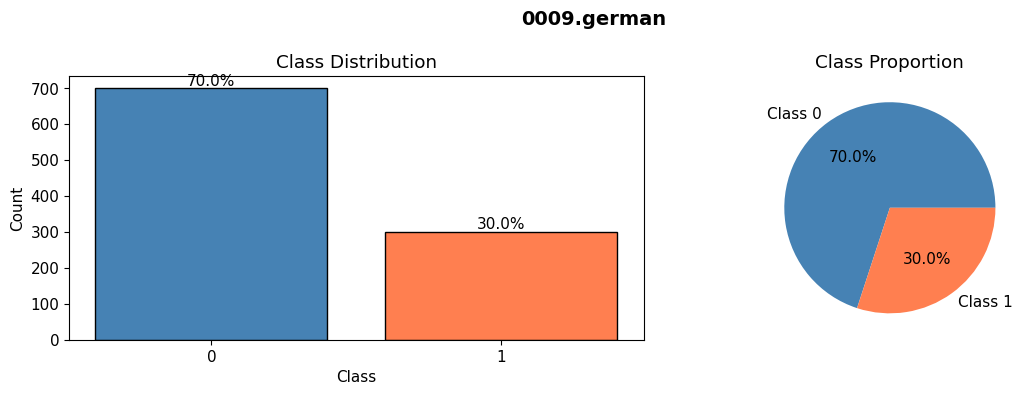

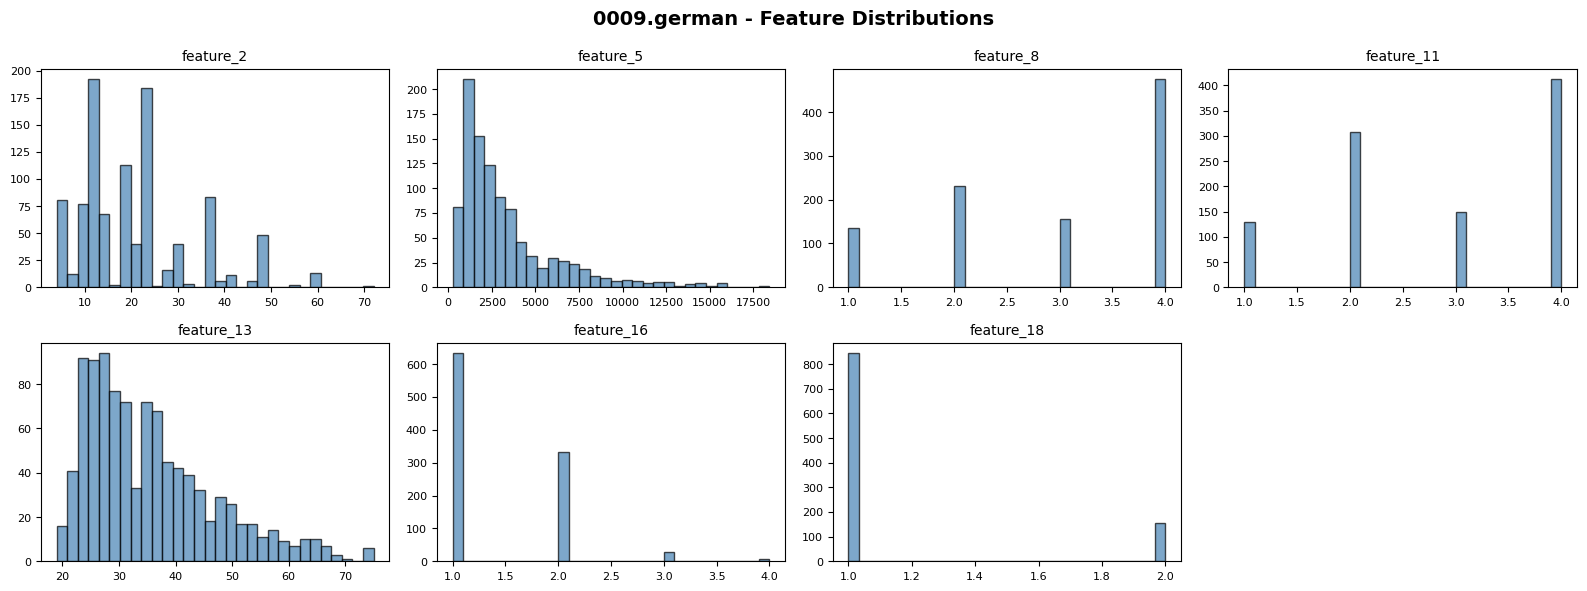

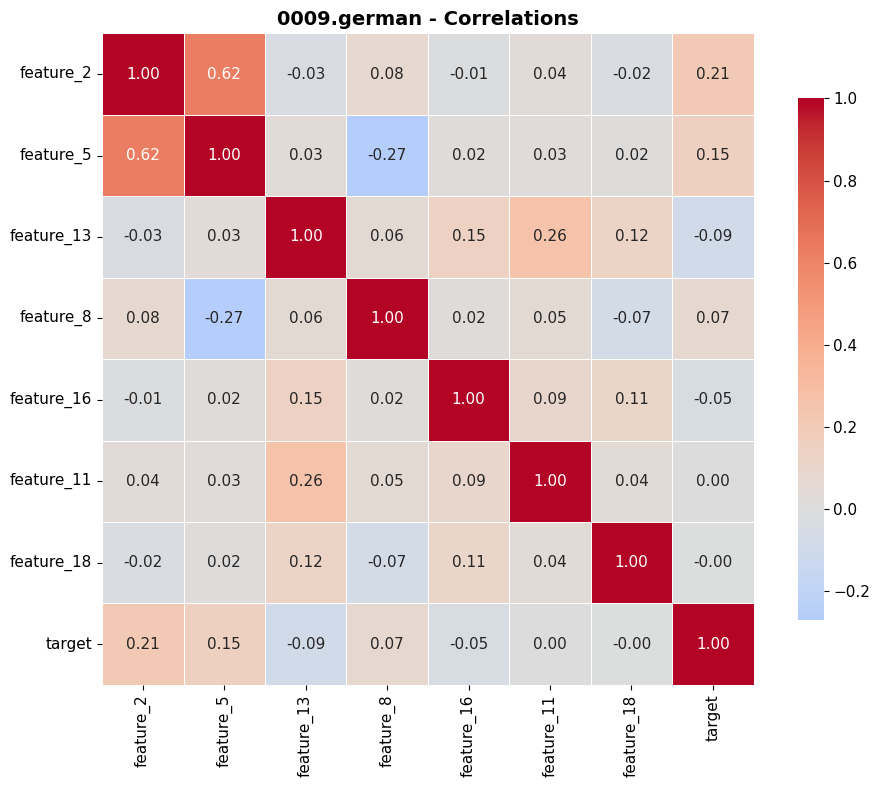


 DATASET: 0010.bank_status (PD)

[BASIC STATISTICS]
  Samples:          100,000
  Numeric features: 16
  Categorical feat: 0
  Total features:   16

[TARGET VARIABLE]
  Class 0: 77,361 (77.4%)
  Class 1: 22,639 (22.6%)
  Imbalance ratio: 3.42:1


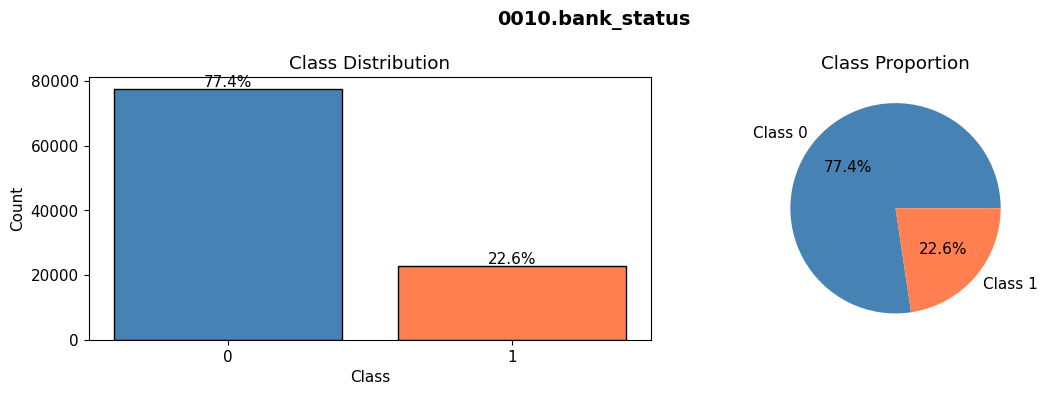

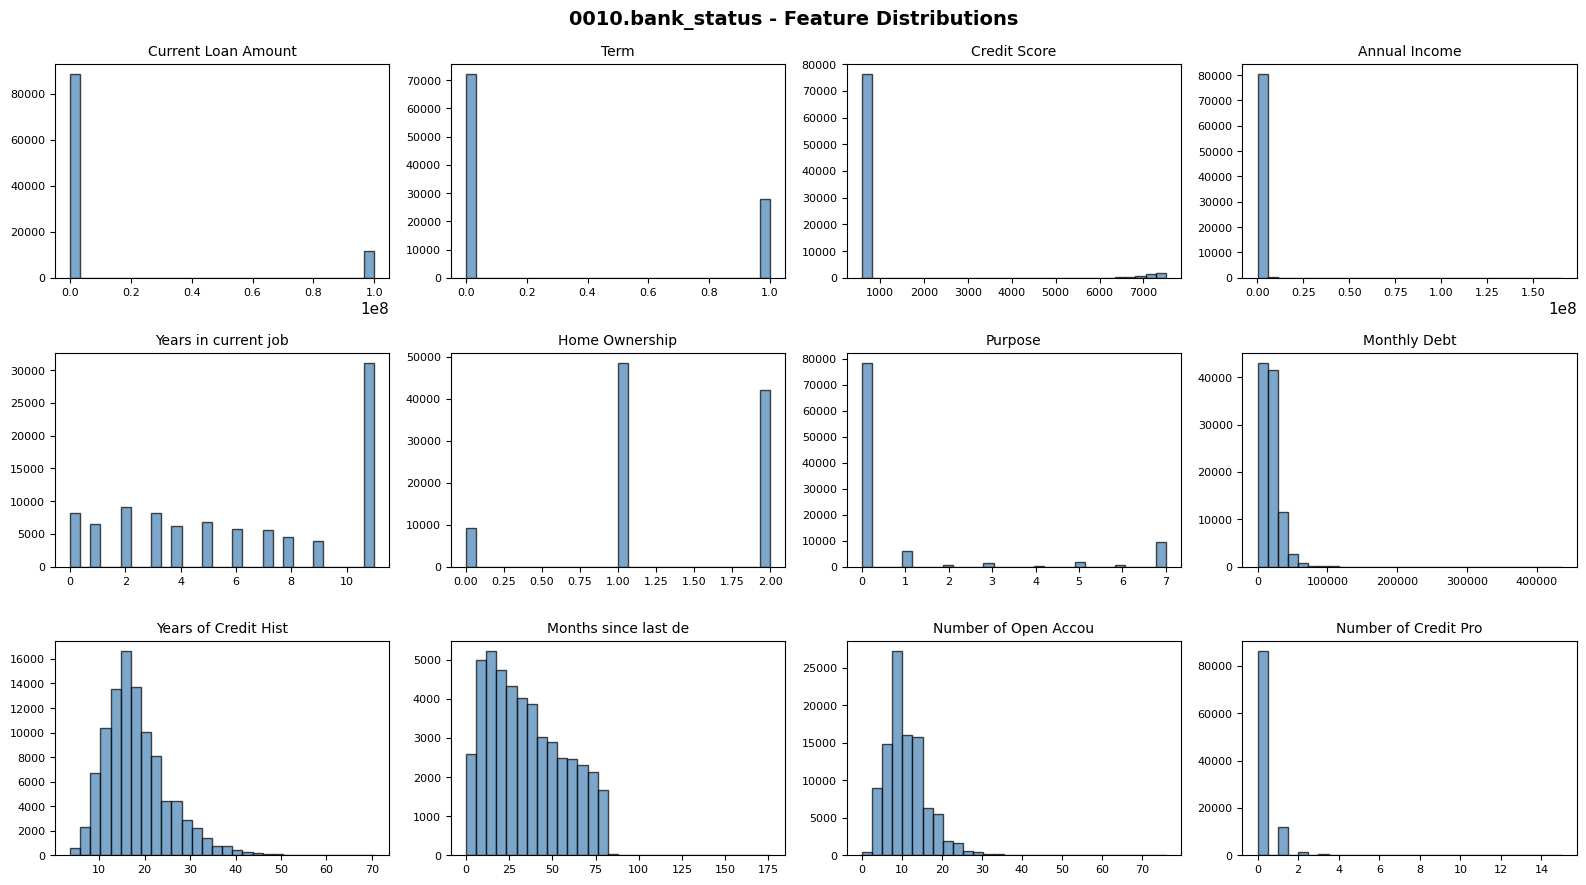

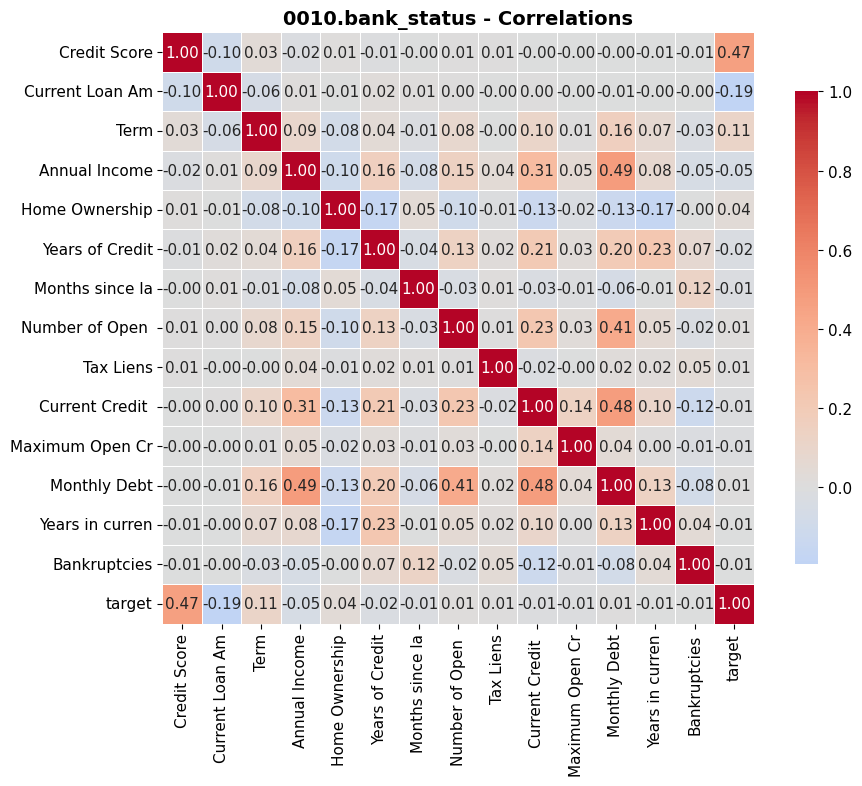


 DATASET: 0011.thomas (PD)

[BASIC STATISTICS]
  Samples:          1,225
  Numeric features: 12
  Categorical feat: 2
  Total features:   14

[TARGET VARIABLE]
  Class 0: 902 (73.6%)
  Class 1: 323 (26.4%)
  Imbalance ratio: 2.79:1


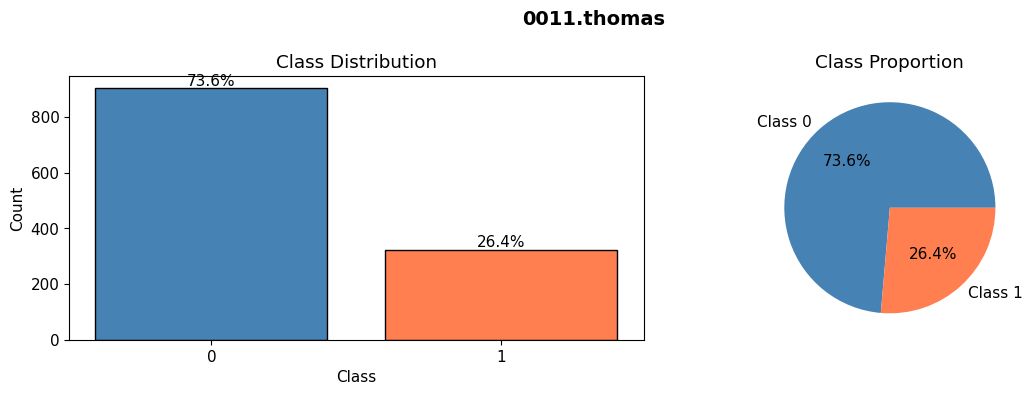

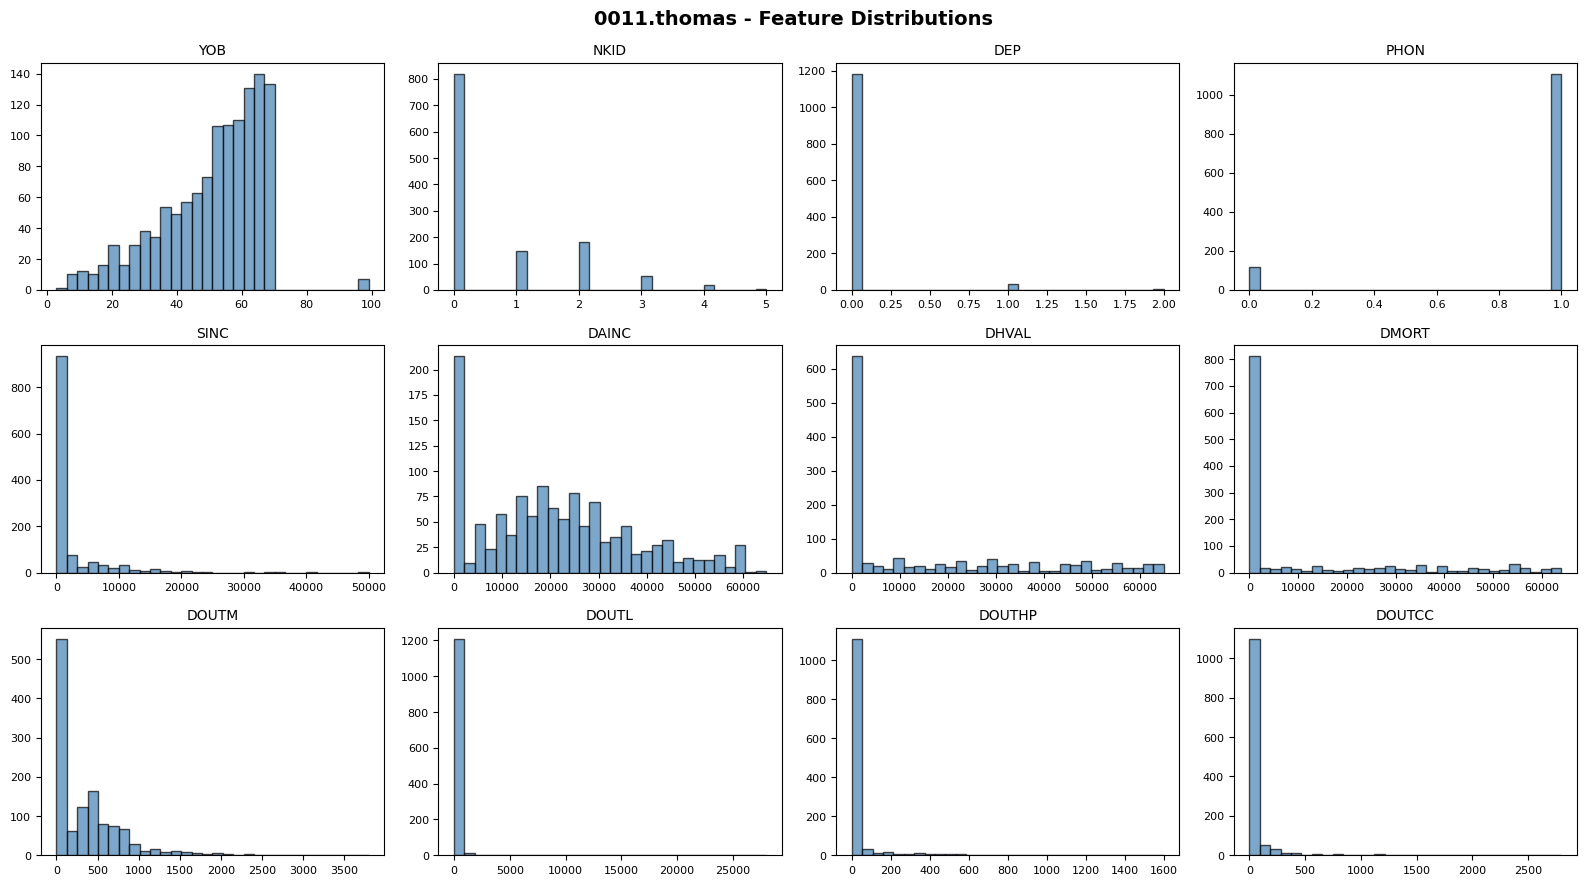

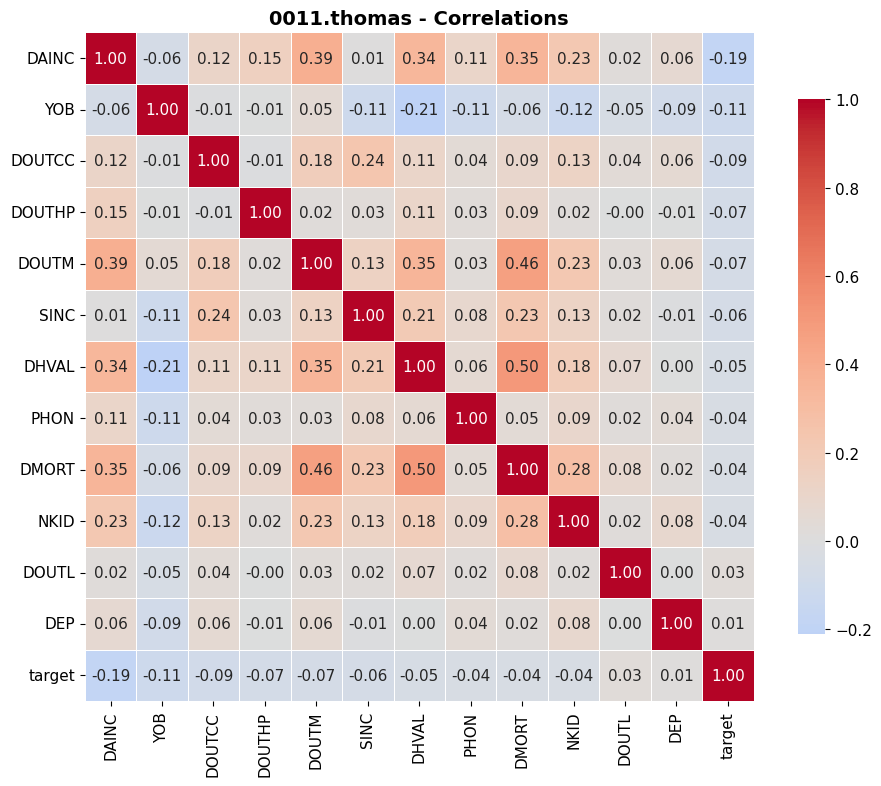


 DATASET: 0012.loan_default (PD)

[BASIC STATISTICS]
  Samples:          105,471
  Numeric features: 99
  Categorical feat: 0
  Total features:   99

[TARGET VARIABLE]
  Class 0: 95,688 (90.7%)
  Class 1: 9,783 (9.3%)
  Imbalance ratio: 9.78:1


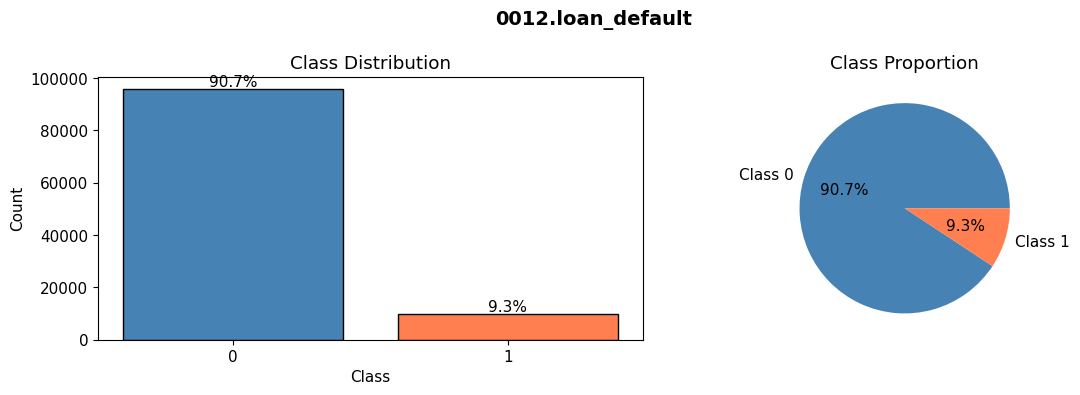

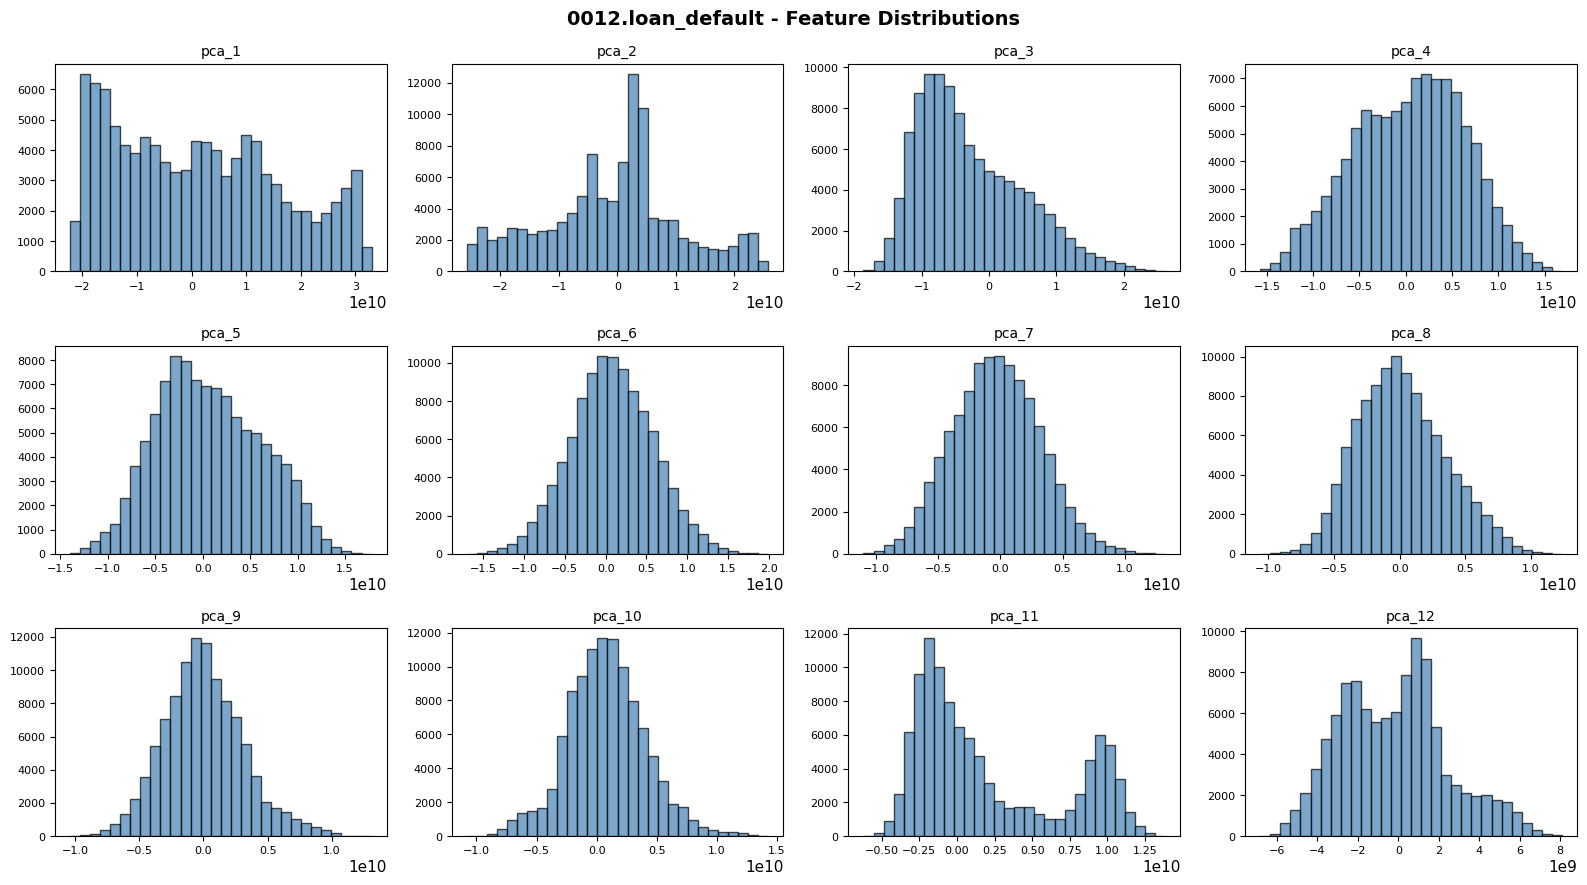

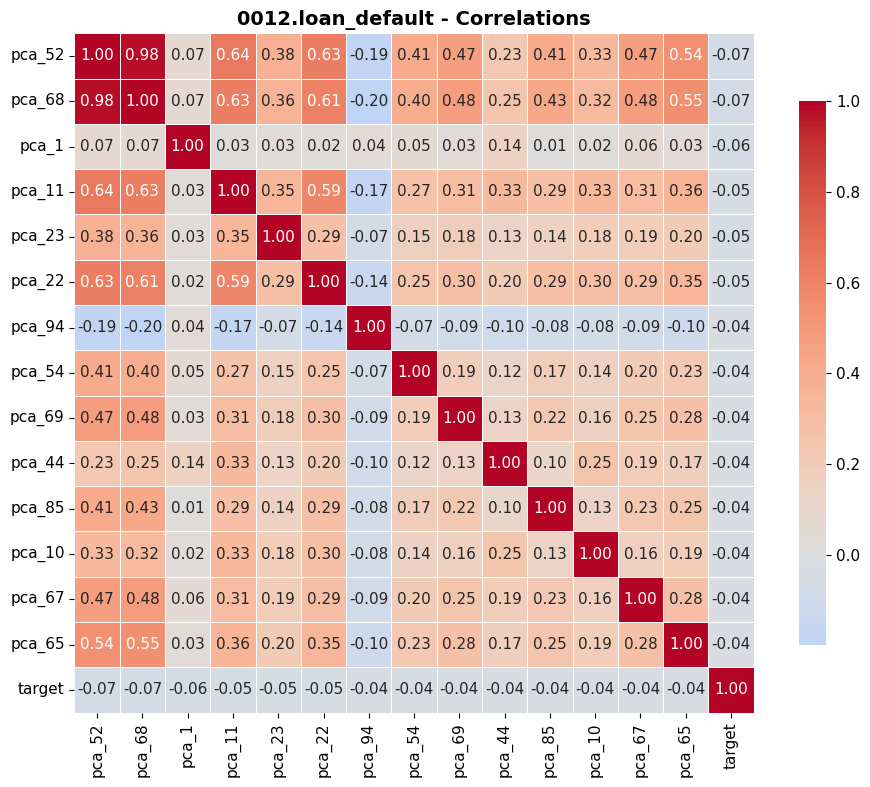


 DATASET: 0013.home_credit (PD)

[BASIC STATISTICS]
  Samples:          307,511
  Numeric features: 99
  Categorical feat: 0
  Total features:   99

[TARGET VARIABLE]
  Class 0: 282,686 (91.9%)
  Class 1: 24,825 (8.1%)
  Imbalance ratio: 11.39:1


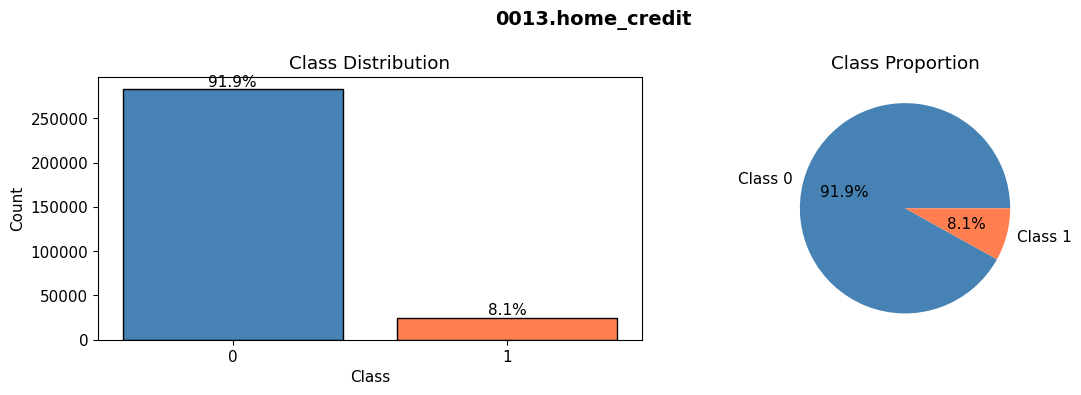

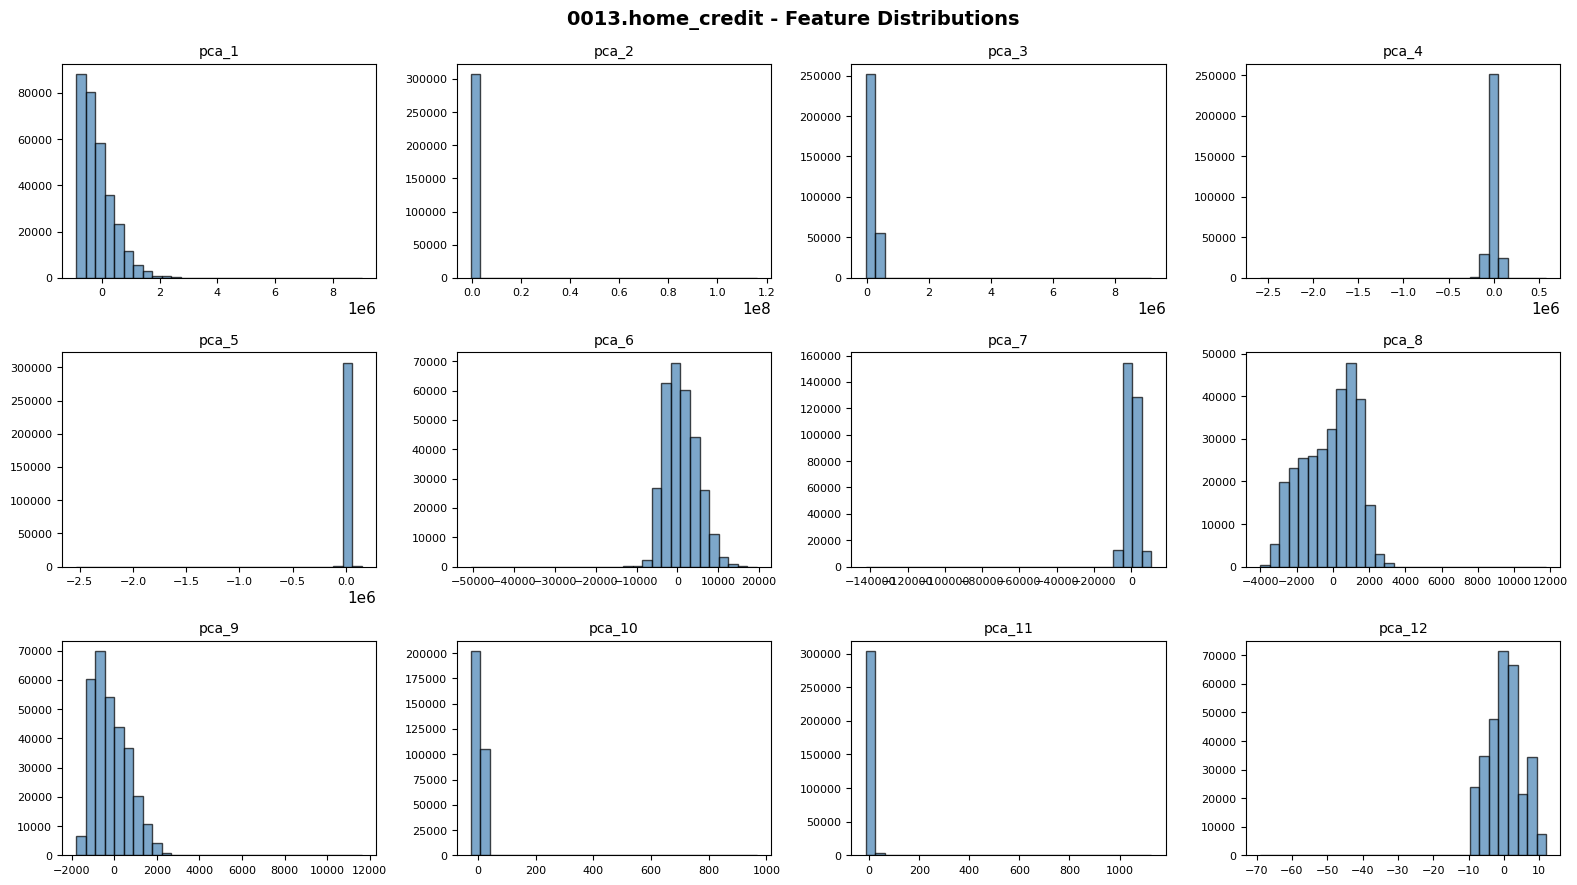

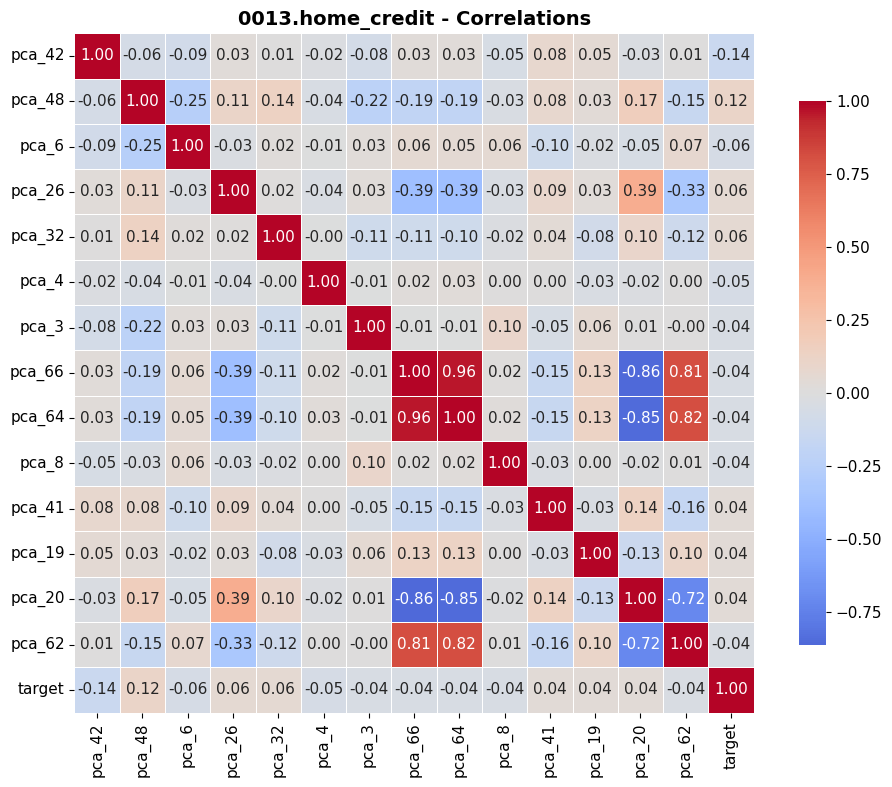


 DATASET: 0014.hmeq (PD)

[BASIC STATISTICS]
  Samples:          5,960
  Numeric features: 10
  Categorical feat: 2
  Total features:   12

[TARGET VARIABLE]
  Class 0: 4,771 (80.1%)
  Class 1: 1,189 (19.9%)
  Imbalance ratio: 4.01:1


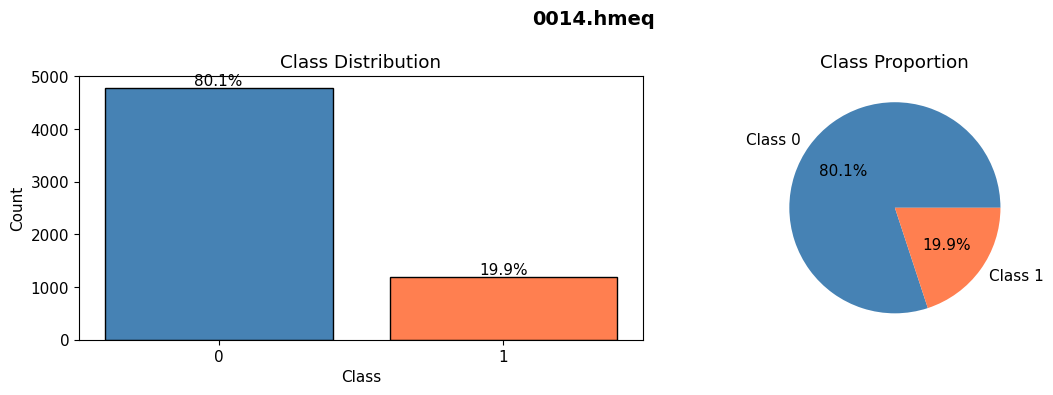

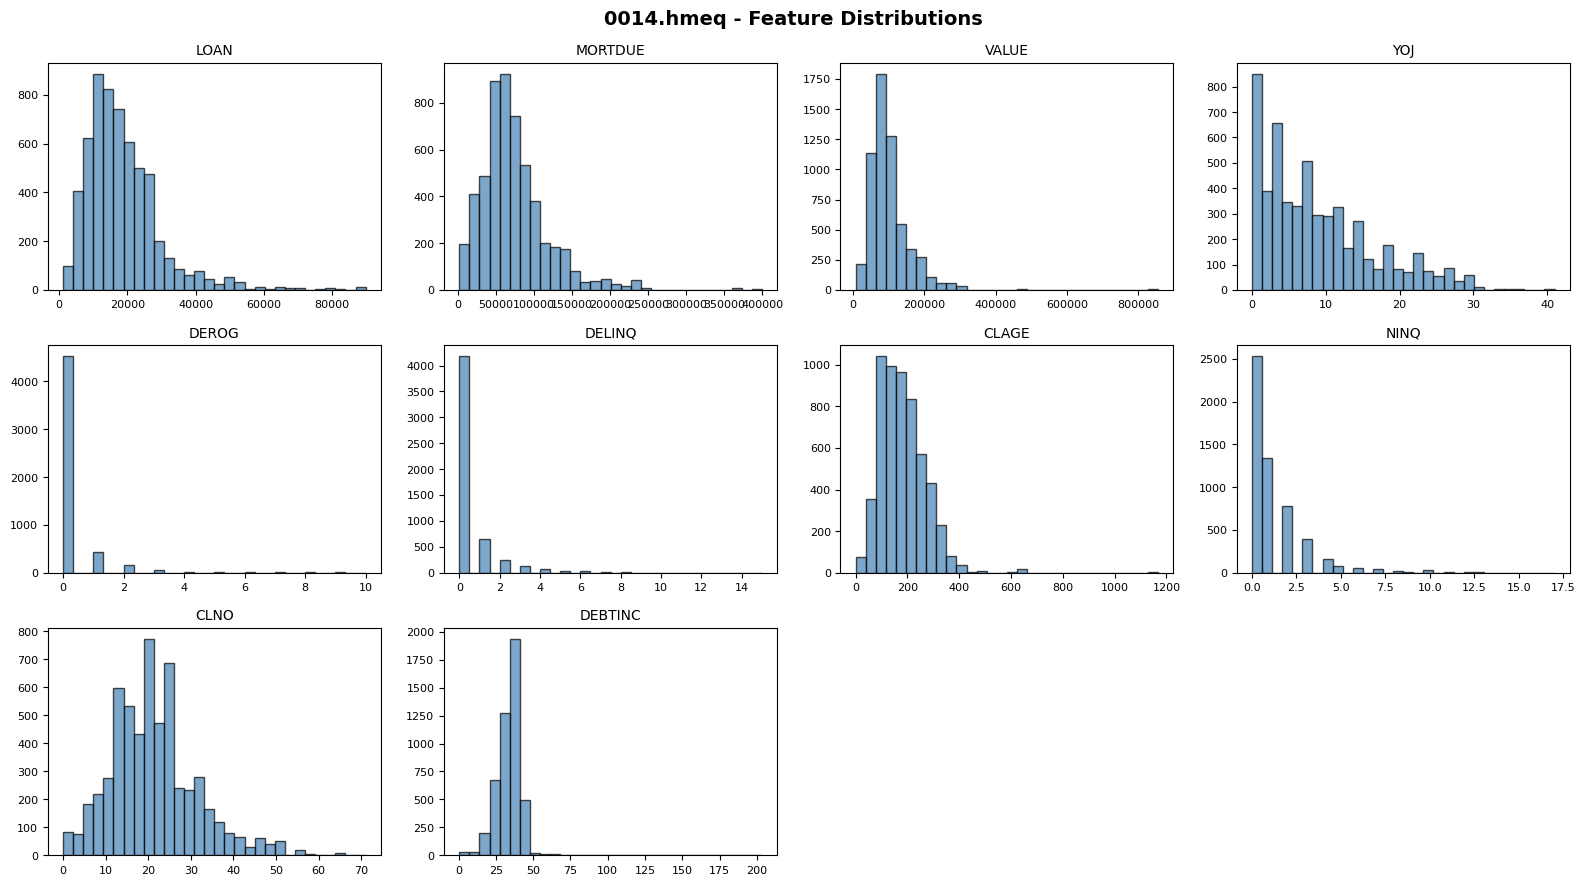

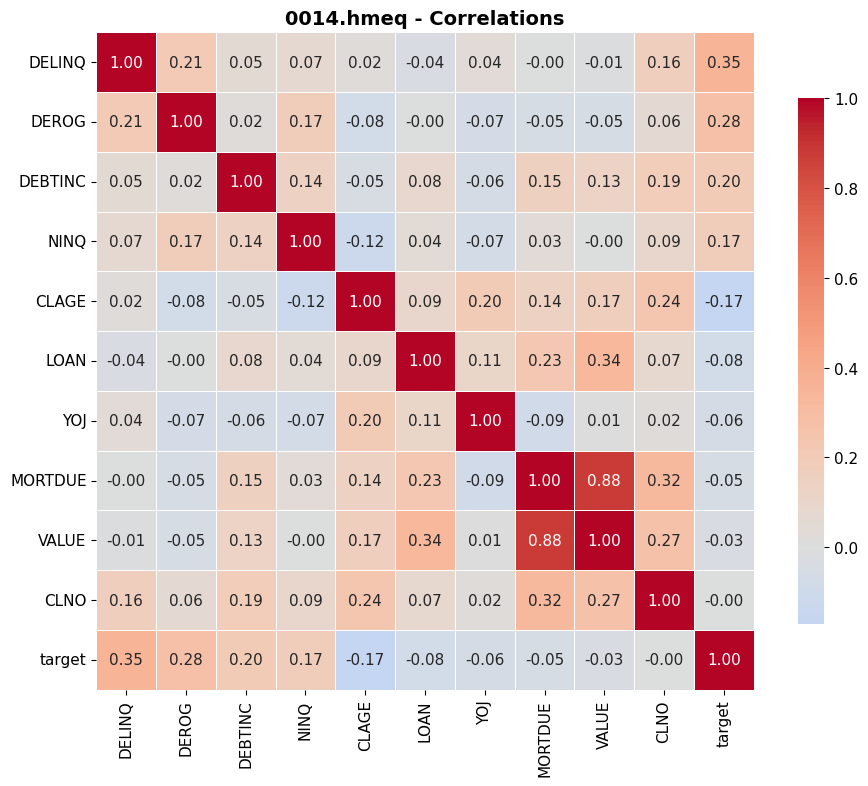


 DATASET: 0015.algorithmwatch (PD)

[BASIC STATISTICS]
  Samples:          158,700
  Numeric features: 99
  Categorical feat: 0
  Total features:   99

[TARGET VARIABLE]
  Class 0: 98,697 (62.2%)
  Class 1: 60,003 (37.8%)
  Imbalance ratio: 1.64:1


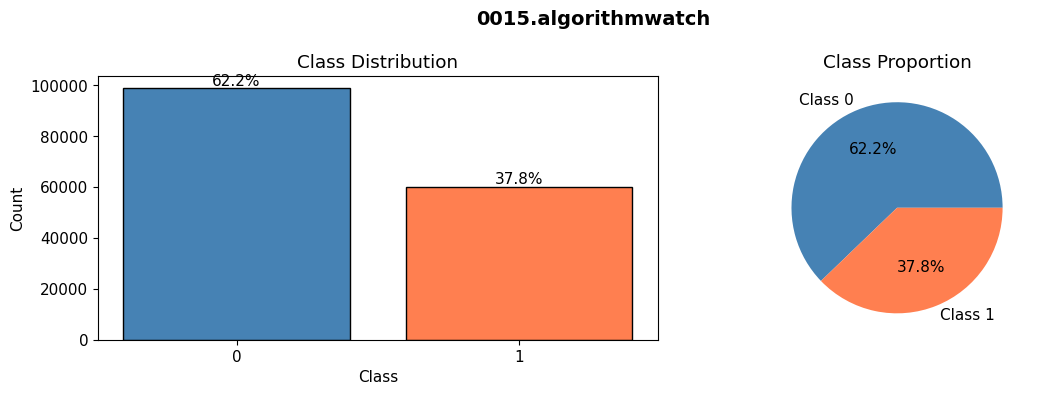

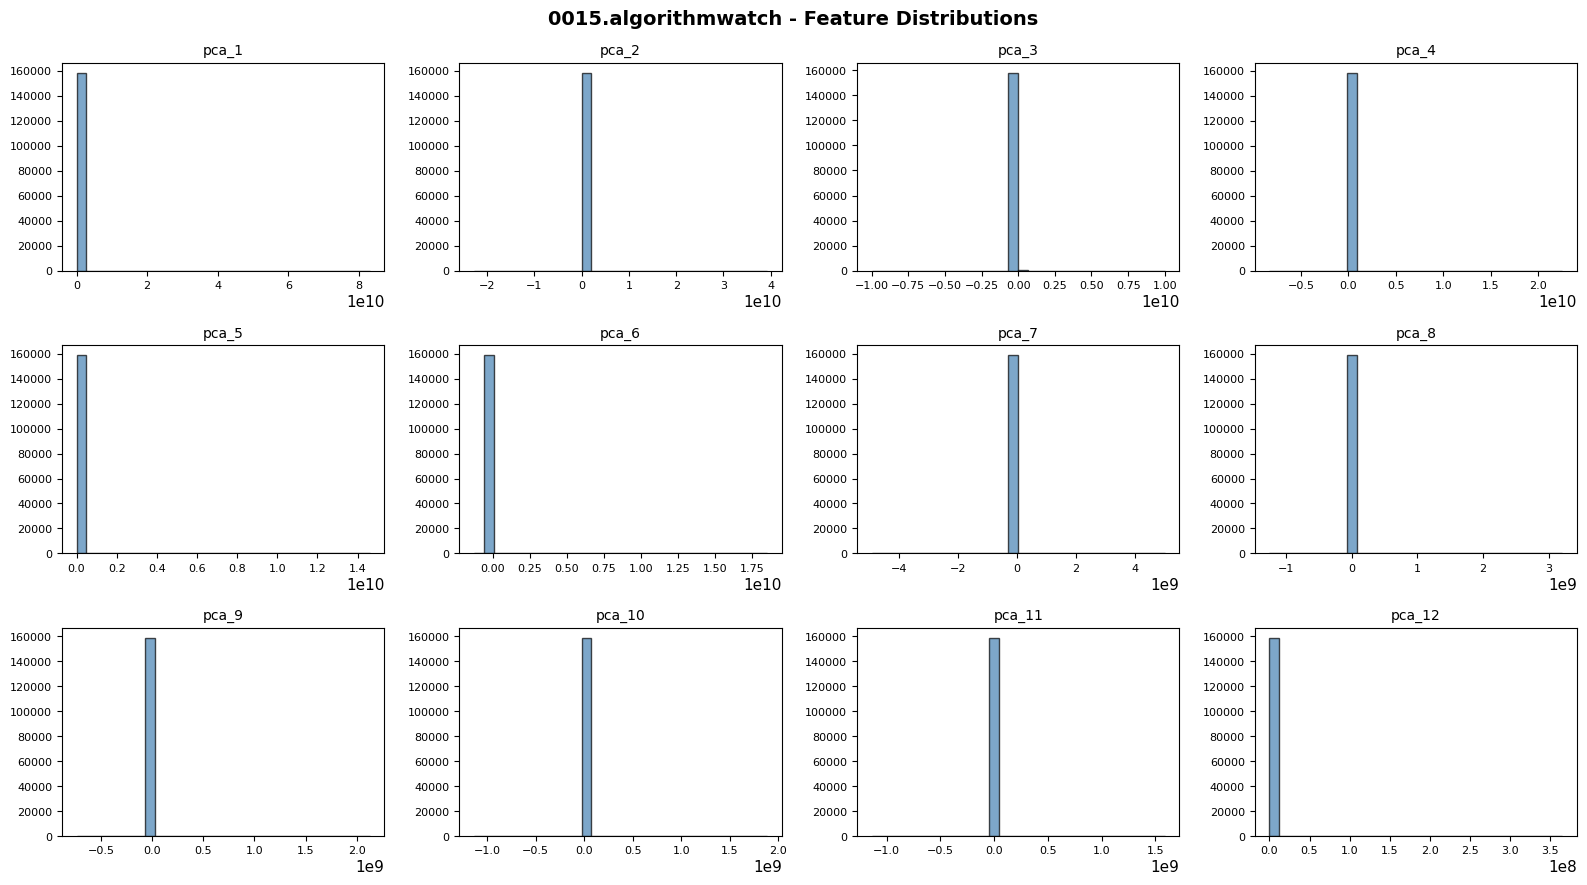

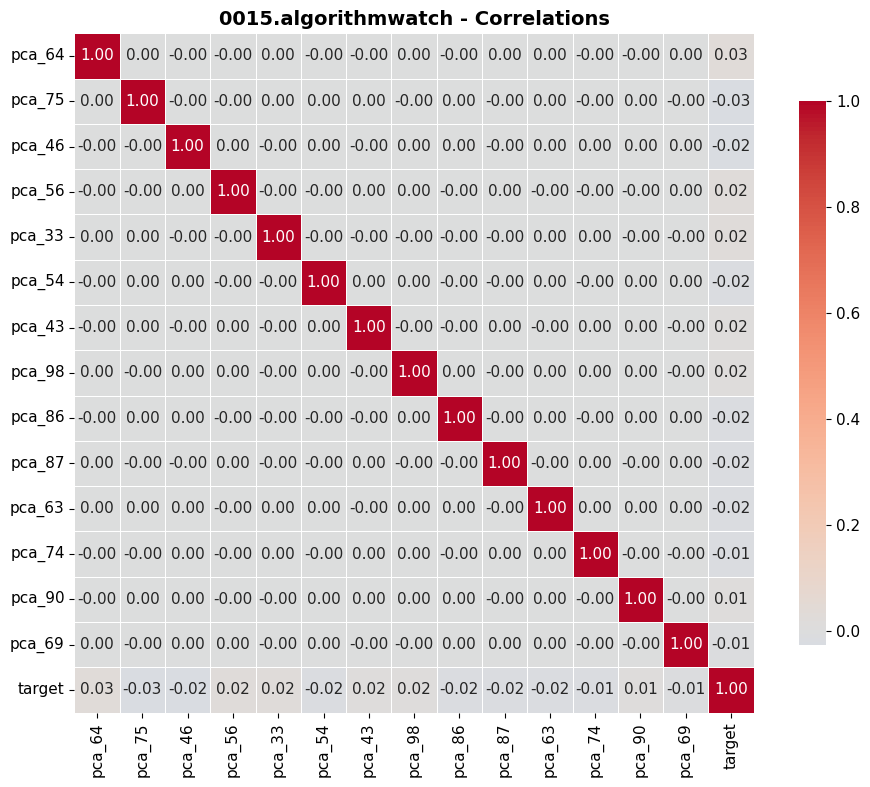

In [7]:
# =============================================================================
# EXPLORE ALL PD DATASETS
# =============================================================================

pd_summaries = []

print(f"Exploring {len(processed_datasets['pd'])} PD datasets...")

for dataset in sorted(processed_datasets['pd']):
    summary = explore_dataset('pd', dataset)
    if summary:
        pd_summaries.append(summary)

---
## Part 4: Explore LGD Datasets

Exploring 5 LGD datasets...

 DATASET: 0001.heloc (LGD)

[BASIC STATISTICS]
  Samples:          67,898
  Numeric features: 9
  Categorical feat: 0
  Total features:   9

[TARGET VARIABLE]
  Min: 0.0000  Max: 1.0000
  Mean: 0.6789  Median: 0.9996  Std: 0.4302
  Values=0: 16729 (24.6%)  Values=1: 33546 (49.4%)


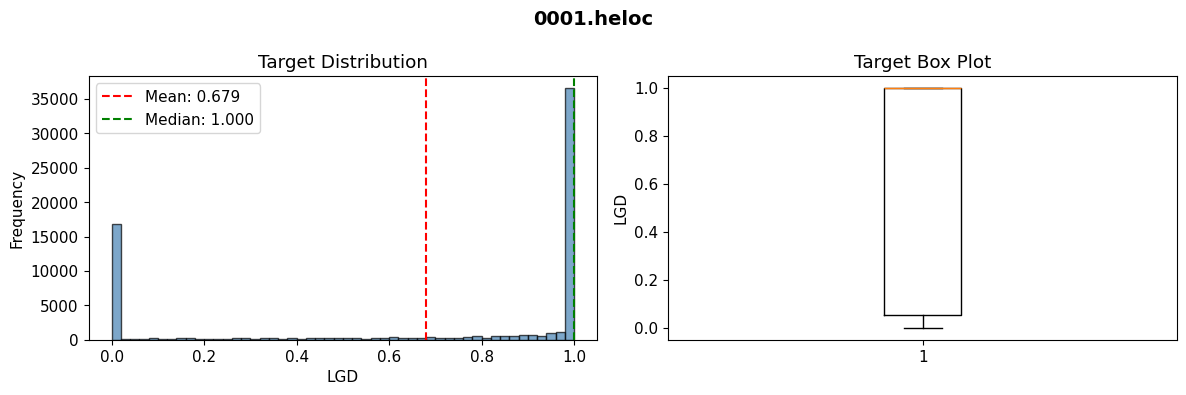

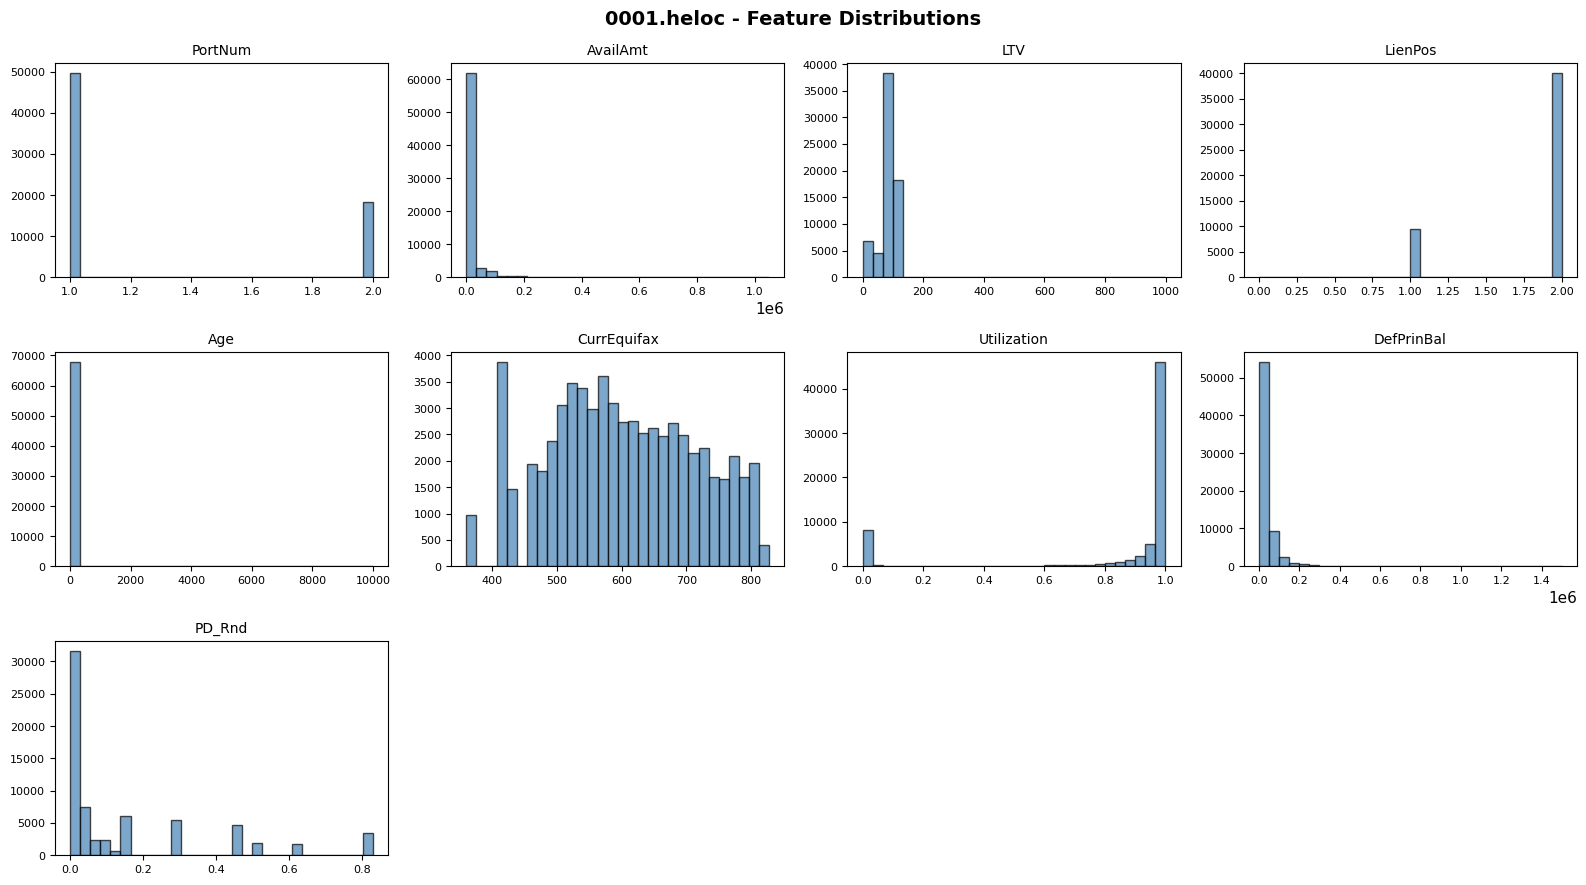

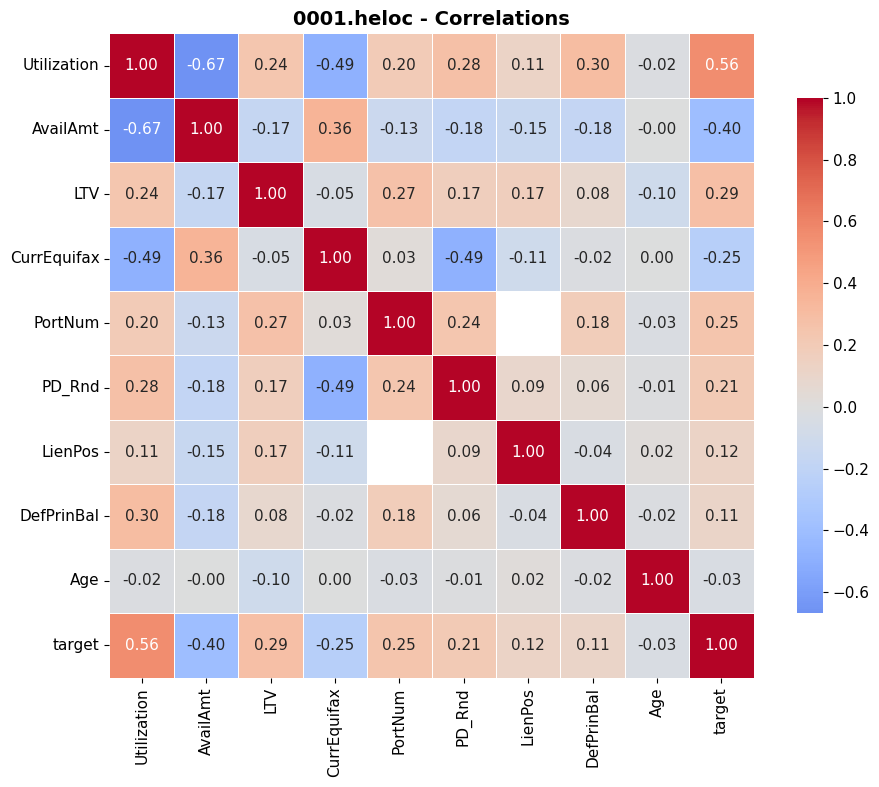


 DATASET: 0002.loss2 (LGD)

[BASIC STATISTICS]
  Samples:          4,638
  Numeric features: 35
  Categorical feat: 23
  Total features:   58

[TARGET VARIABLE]
  Min: 0.0000  Max: 1.0000
  Mean: 0.3920  Median: 0.3515  Std: 0.2713
  Values=0: 168 (3.6%)  Values=1: 172 (3.7%)


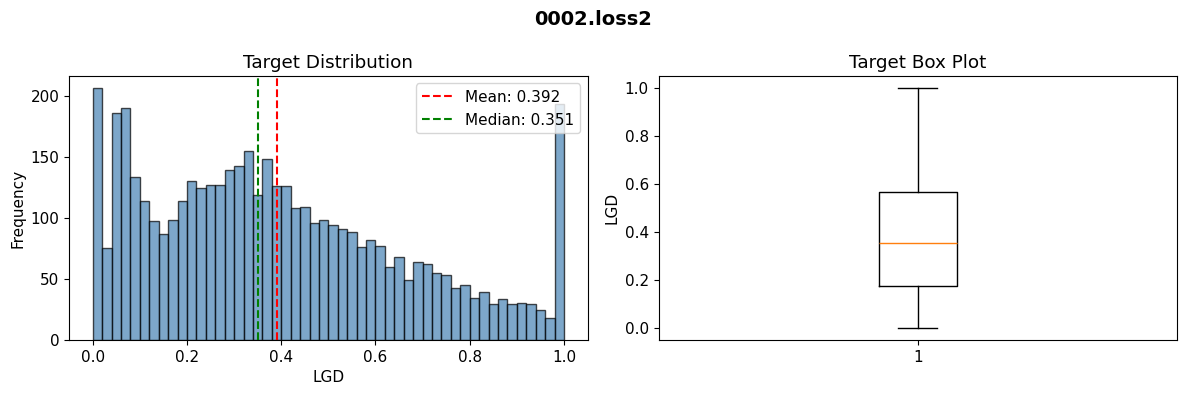

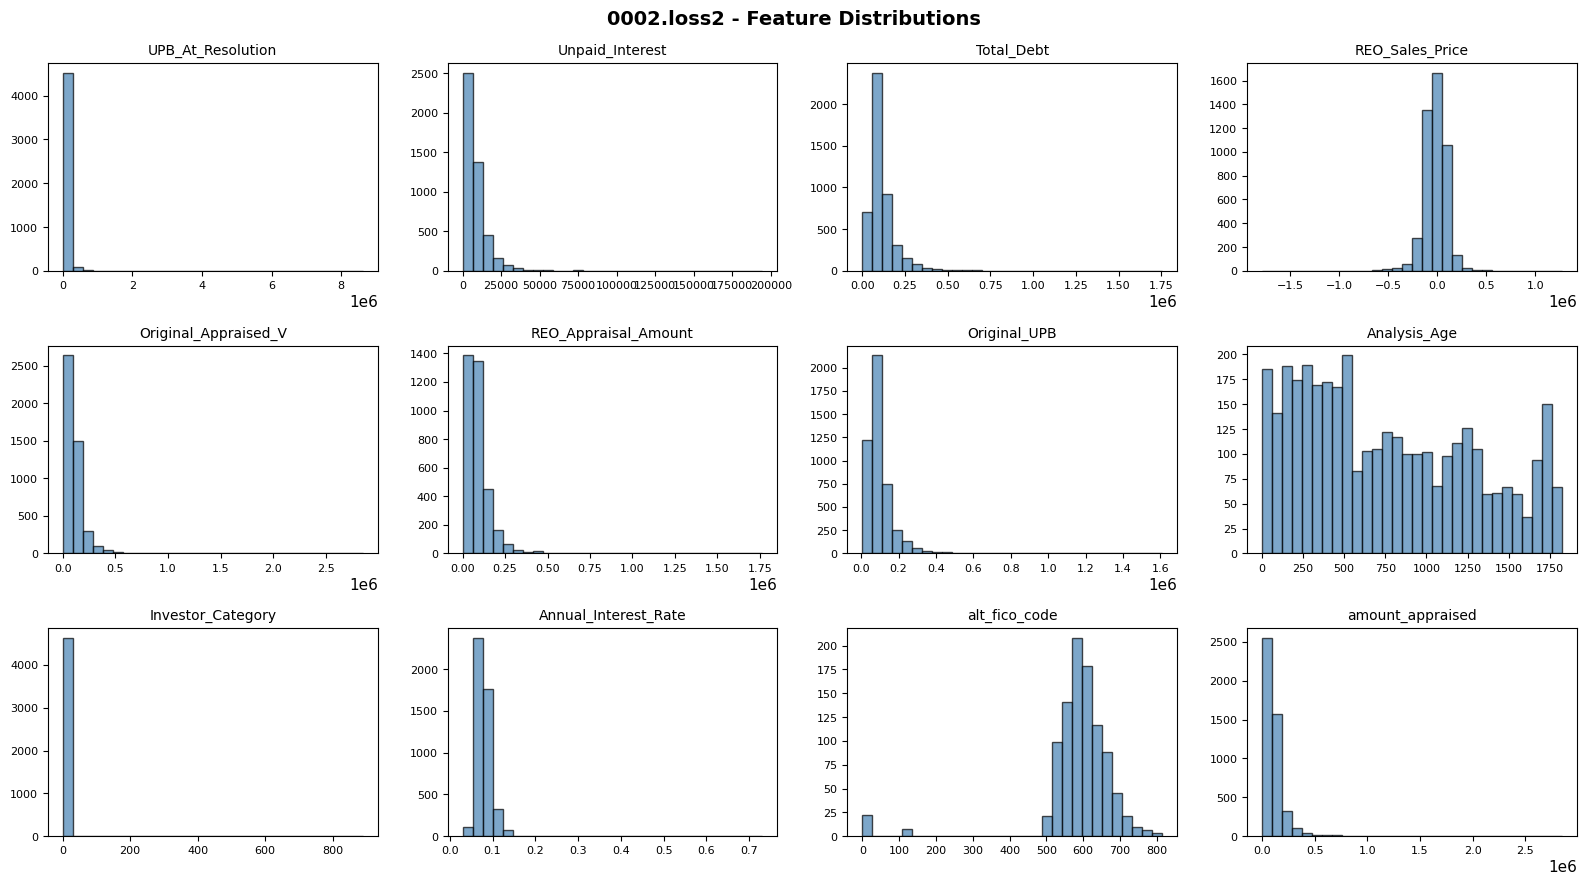

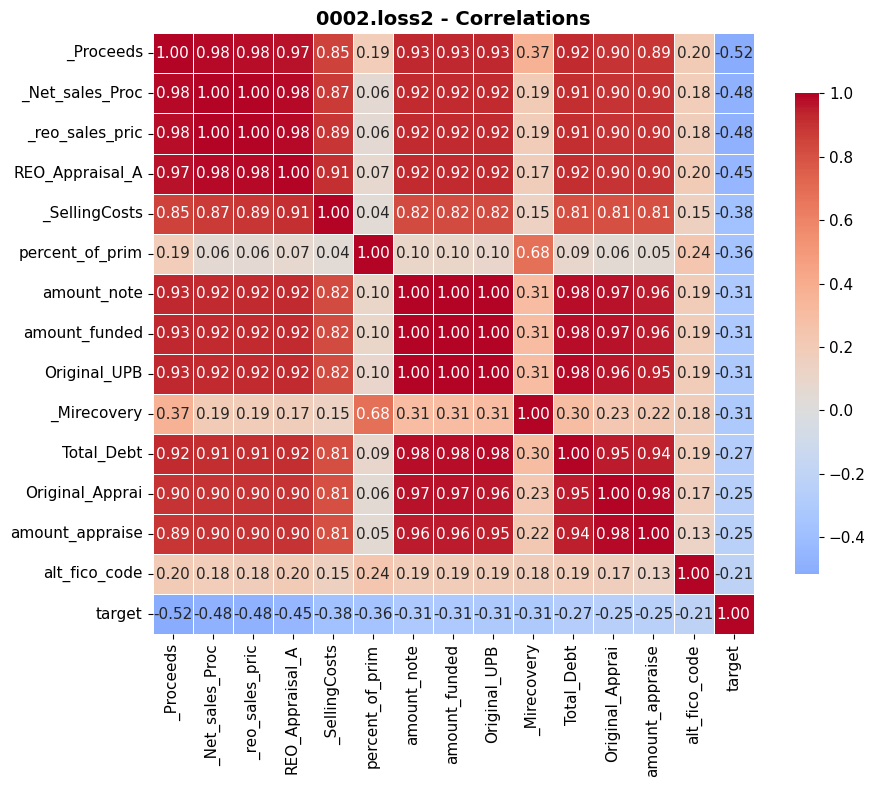


 DATASET: 0003.axa (LGD)

[BASIC STATISTICS]
  Samples:          2,545
  Numeric features: 2
  Categorical feat: 0
  Total features:   2

[TARGET VARIABLE]
  Min: 0.0000  Max: 1.0000
  Mean: 0.2281  Median: 0.0321  Std: 0.3290
  Values=0: 0 (0.0%)  Values=1: 0 (0.0%)


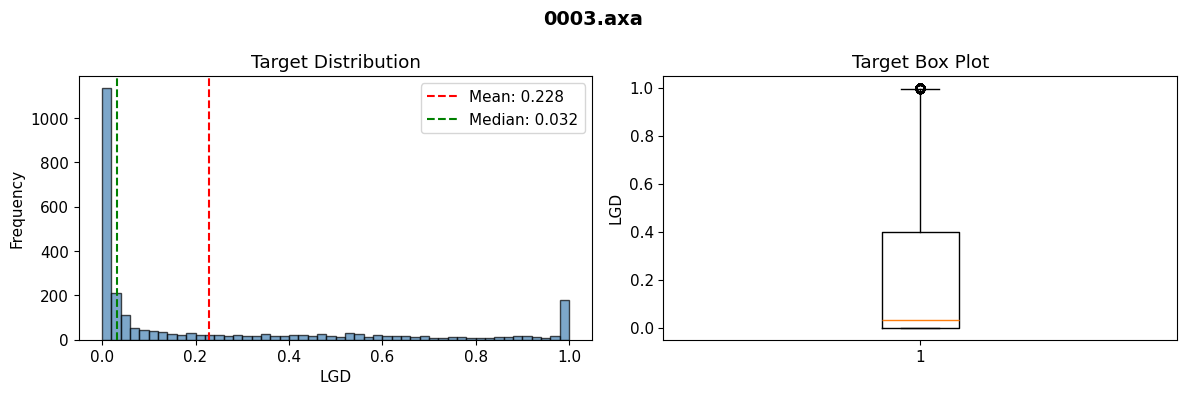

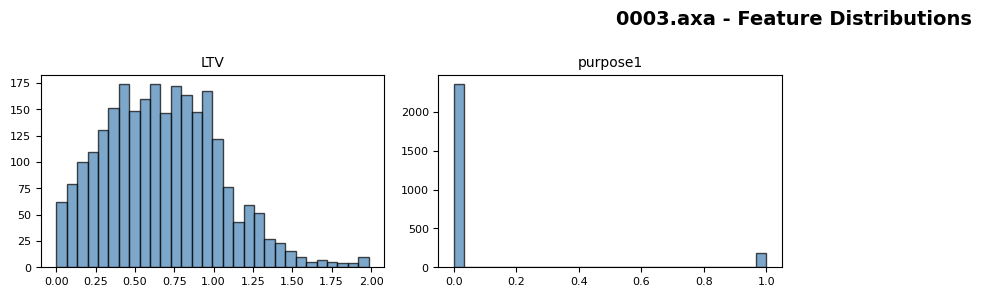

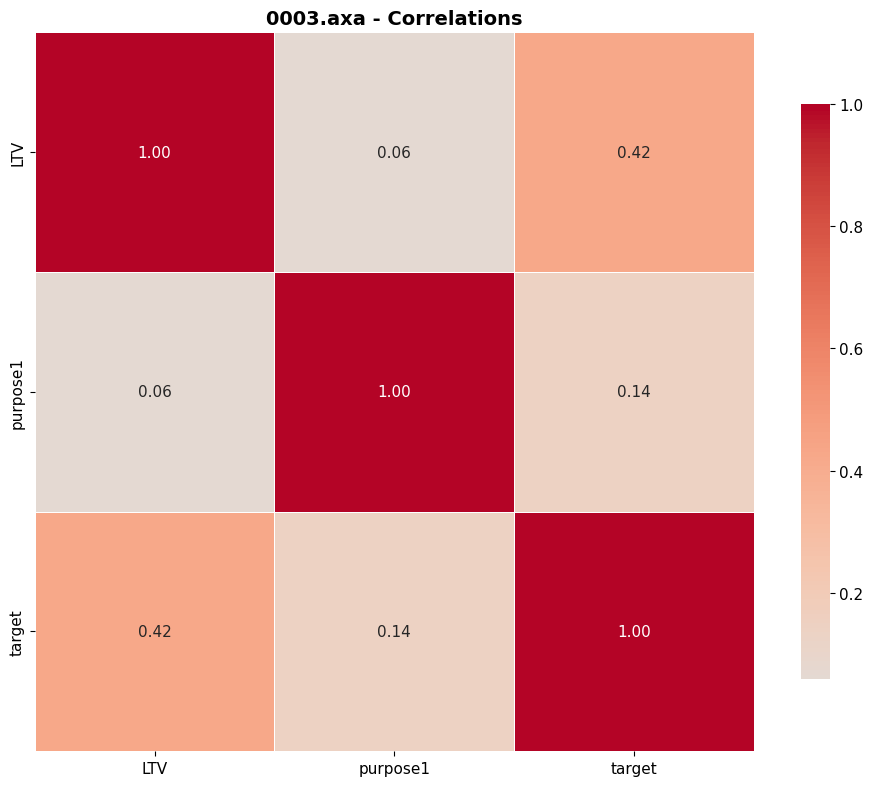


 DATASET: 0004.base_model (LGD)

[BASIC STATISTICS]
  Samples:          759
  Numeric features: 10
  Categorical feat: 0
  Total features:   10

[TARGET VARIABLE]
  Min: 0.0000  Max: 1.0000
  Mean: 0.3228  Median: 0.1032  Std: 0.3774
  Values=0: 80 (10.5%)  Values=1: 91 (12.0%)


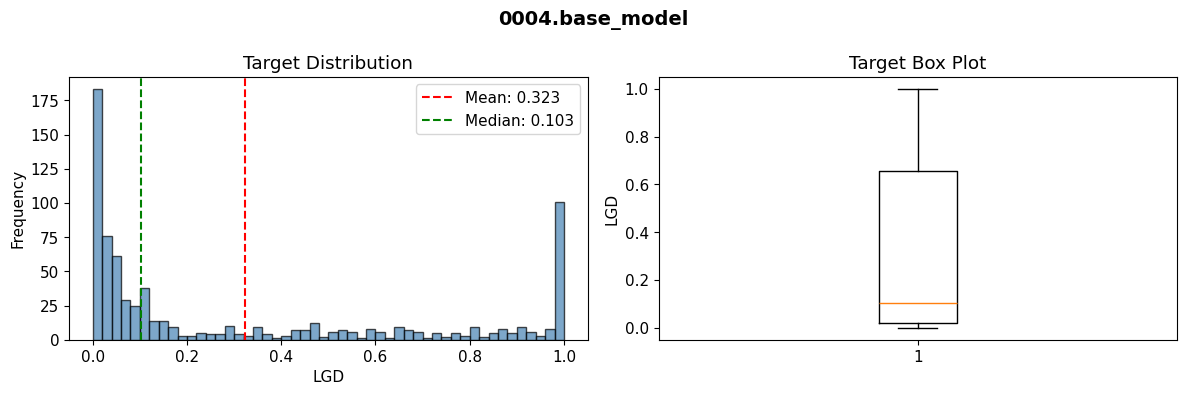

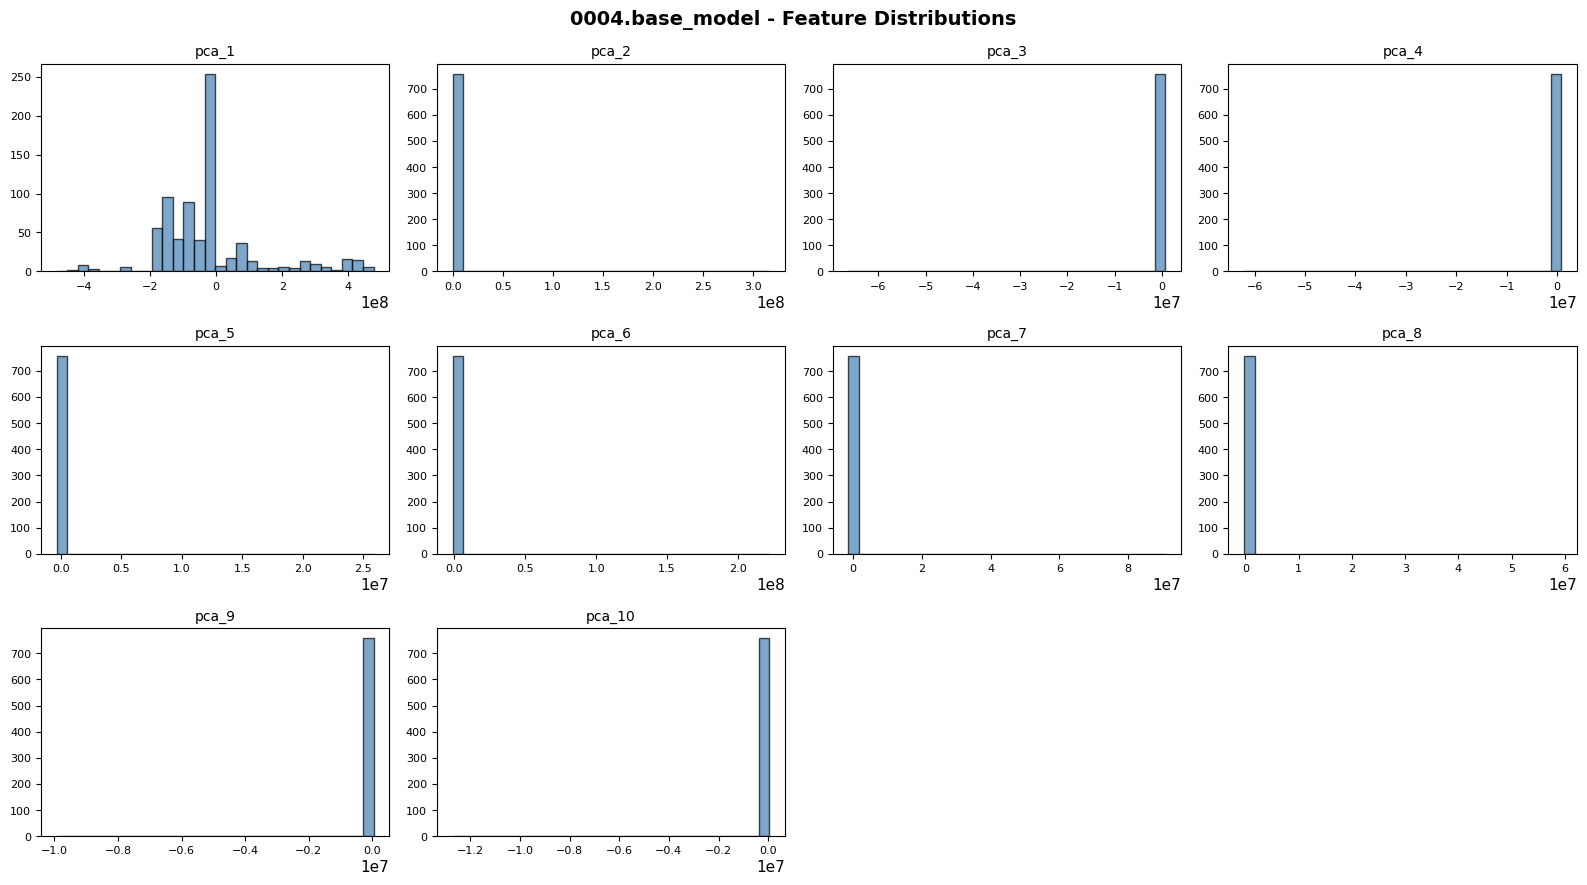

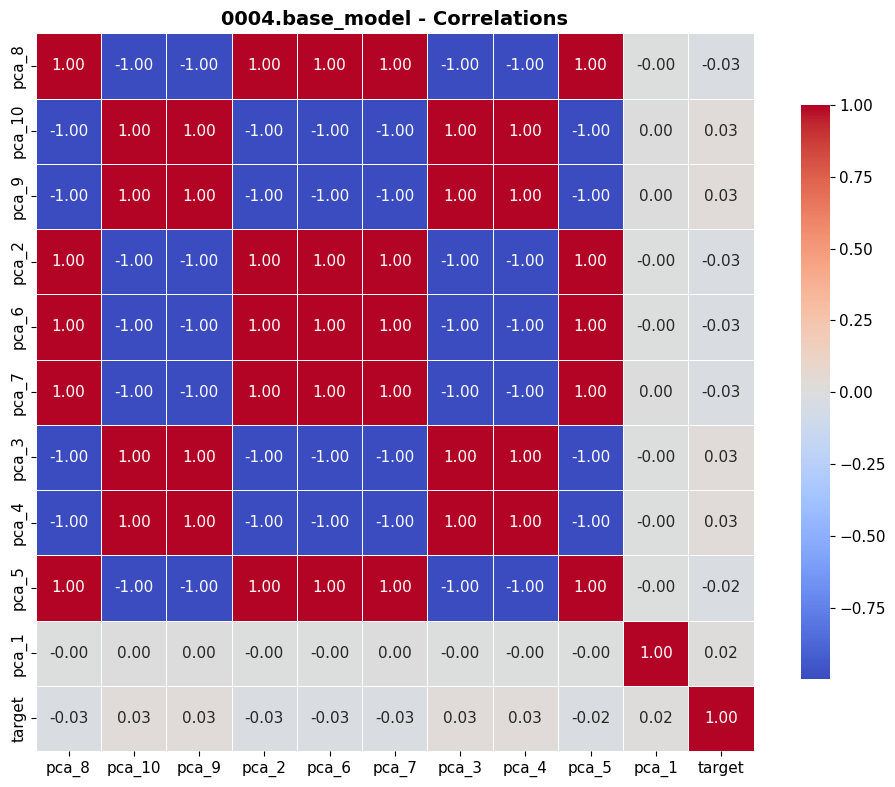


 DATASET: 0005.base_modelisation (LGD)

[BASIC STATISTICS]
  Samples:          594
  Numeric features: 99
  Categorical feat: 0
  Total features:   99

[TARGET VARIABLE]
  Min: 0.0000  Max: 1.0000
  Mean: 0.3301  Median: 0.0435  Std: 0.4094
  Values=0: 69 (11.6%)  Values=1: 95 (16.0%)


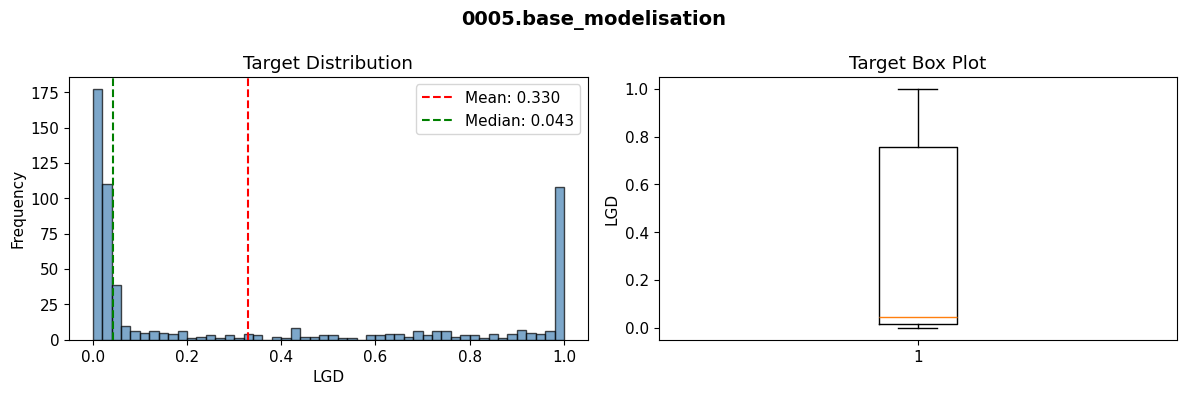

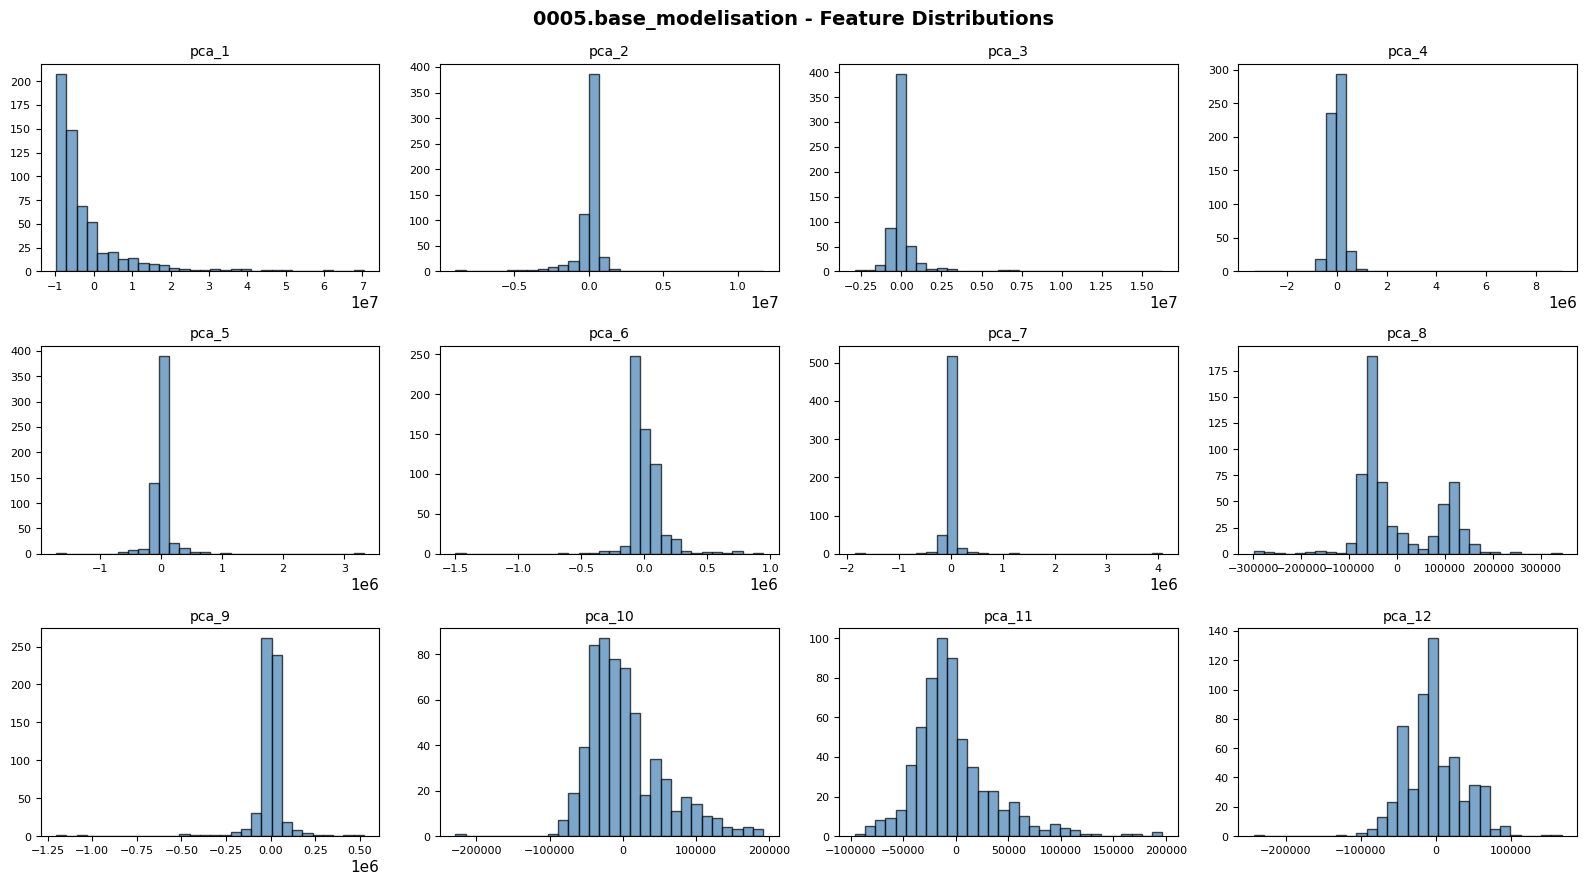

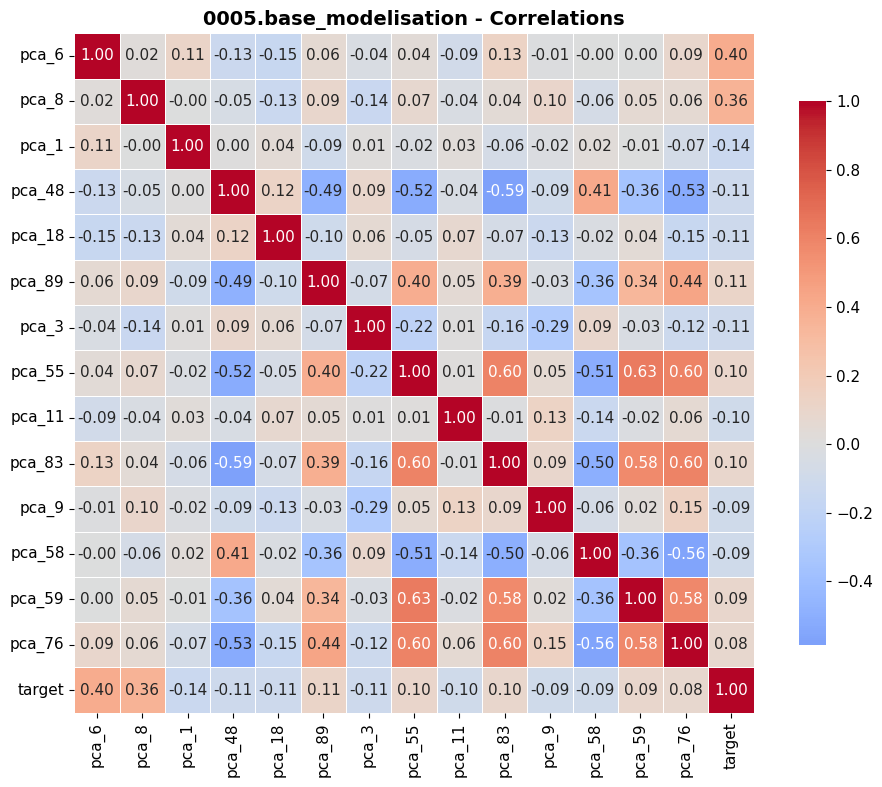

In [8]:
# =============================================================================
# EXPLORE ALL LGD DATASETS
# =============================================================================

lgd_summaries = []

print(f"Exploring {len(processed_datasets['lgd'])} LGD datasets...")

for dataset in sorted(processed_datasets['lgd']):
    summary = explore_dataset('lgd', dataset)
    if summary:
        lgd_summaries.append(summary)

---
## Part 5: Summary Comparison

In [9]:
# =============================================================================
# SUMMARY TABLE
# =============================================================================

print("=" * 80)
print(" DATASET SUMMARY TABLE")
print("=" * 80)

all_summaries = pd_summaries + lgd_summaries

if all_summaries:
    summary_df = pd.DataFrame(all_summaries)
    summary_df.columns = ['Dataset', 'Task', 'Samples', 'Numeric', 'Categorical', 'Total Features']
    print("\n")
    print(summary_df.to_string(index=False))
else:
    print("No datasets loaded.")

 DATASET SUMMARY TABLE


               Dataset Task  Samples  Numeric  Categorical  Total Features
             0001.gmsc   pd   150000       10            0              10
0002.taiwan_creditcard   pd    30000       23            0              23
     0003.vehicle_loan   pd   233154       32            3              35
      0004.lendingclub   pd     9578       12            1              13
       0005.case_study   pd   150000       10            1              11
            0006.myhom   pd     7000        7            1               8
      0007.hackerearth   pd   532428       35            8              43
        0008.cobranded   pd    80000       47            0              47
           0009.german   pd      999        7           13              20
      0010.bank_status   pd   100000       16            0              16
           0011.thomas   pd     1225       12            2              14
     0012.loan_default   pd   105471       99            0              99


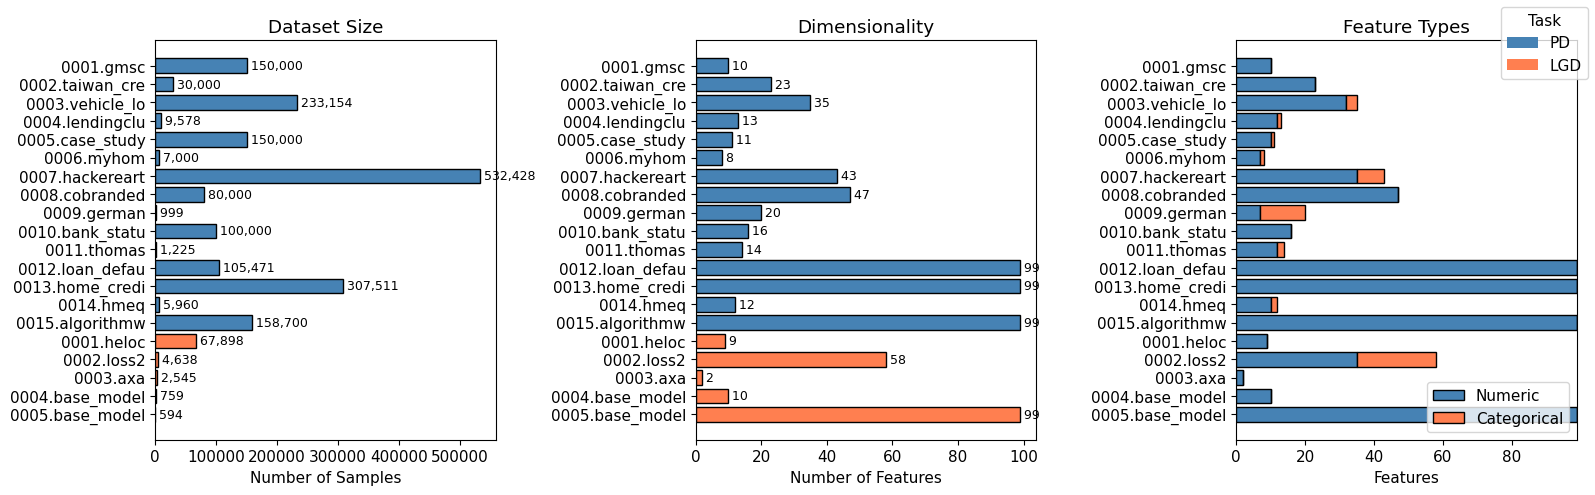

In [10]:
# =============================================================================
# VISUALIZATION: DATASET COMPARISON
# =============================================================================

if all_summaries:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    names = [s['name'][:15] for s in all_summaries]
    samples = [s['n_samples'] for s in all_summaries]
    features = [s['n_total_features'] for s in all_summaries]
    tasks = [s['task'] for s in all_summaries]
    colors = ['steelblue' if t == 'pd' else 'coral' for t in tasks]
    
    # Samples
    bars1 = axes[0].barh(names, samples, color=colors, edgecolor='black')
    axes[0].set_xlabel('Number of Samples')
    axes[0].set_title('Dataset Size')
    axes[0].invert_yaxis()
    for bar, val in zip(bars1, samples):
        axes[0].text(val, bar.get_y() + bar.get_height()/2, f' {val:,}', va='center', fontsize=9)
    
    # Features
    bars2 = axes[1].barh(names, features, color=colors, edgecolor='black')
    axes[1].set_xlabel('Number of Features')
    axes[1].set_title('Dimensionality')
    axes[1].invert_yaxis()
    for bar, val in zip(bars2, features):
        axes[1].text(val, bar.get_y() + bar.get_height()/2, f' {val}', va='center', fontsize=9)
    
    # Feature types
    n_num = [s['n_num_features'] for s in all_summaries]
    n_cat = [s['n_cat_features'] for s in all_summaries]
    y_pos = np.arange(len(names))
    axes[2].barh(y_pos, n_num, label='Numeric', color='steelblue', edgecolor='black')
    axes[2].barh(y_pos, n_cat, left=n_num, label='Categorical', color='coral', edgecolor='black')
    axes[2].set_yticks(y_pos)
    axes[2].set_yticklabels(names)
    axes[2].set_xlabel('Features')
    axes[2].set_title('Feature Types')
    axes[2].legend(loc='lower right')
    axes[2].invert_yaxis()
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='steelblue', label='PD'), Patch(facecolor='coral', label='LGD')]
    fig.legend(handles=legend_elements, loc='upper right', title='Task')
    
    plt.tight_layout()
    plt.show()

In [11]:
# =============================================================================
# TASK-SPECIFIC STATISTICS
# =============================================================================

print("=" * 80)
print(" TASK-SPECIFIC SUMMARY")
print("=" * 80)

if pd_summaries:
    print("\n[PD DATASETS (Classification)]")
    print(f"  Total datasets:       {len(pd_summaries)}")
    print(f"  Total samples:        {sum(s['n_samples'] for s in pd_summaries):,}")
    print(f"  Avg samples/dataset:  {np.mean([s['n_samples'] for s in pd_summaries]):,.0f}")
    print(f"  Avg features/dataset: {np.mean([s['n_total_features'] for s in pd_summaries]):.1f}")

if lgd_summaries:
    print("\n[LGD DATASETS (Regression)]")
    print(f"  Total datasets:       {len(lgd_summaries)}")
    print(f"  Total samples:        {sum(s['n_samples'] for s in lgd_summaries):,}")
    print(f"  Avg samples/dataset:  {np.mean([s['n_samples'] for s in lgd_summaries]):,.0f}")
    print(f"  Avg features/dataset: {np.mean([s['n_total_features'] for s in lgd_summaries]):.1f}")

 TASK-SPECIFIC SUMMARY

[PD DATASETS (Classification)]
  Total datasets:       15
  Total samples:        1,872,026
  Avg samples/dataset:  124,802
  Avg features/dataset: 36.6

[LGD DATASETS (Regression)]
  Total datasets:       5
  Total samples:        76,434
  Avg samples/dataset:  15,287
  Avg features/dataset: 35.6


---
## Summary

This notebook has:

1. **Preprocessed** all raw datasets using `src.data.preprocessing.preprocess_dataset()`
2. **Explored** each dataset with:
   - Basic statistics (samples, features)
   - Target distribution analysis
   - Feature distribution visualizations
   - Correlation heatmaps
3. **Compared** all datasets with summary tables and visualizations